# Trabalho prático 2 ANADI

## 4.1 - Análise exploratória de dados

### 4.1.1 - Carregamento, dimensão e sumário dos dados

Depois de carregar o ficheiro, foi analisada a sua dimensão, ou seja, o número de registos que corresponde ao número de linhas e o número de variáveis que corresponde ao número de colunas.

In [46]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Carregar o ficheiro
# ------------------------------------------------------------
df = pd.read_excel("PTD_level_dataset.xlsx")

# ------------------------------------------------------------
# 2. Dimensão do dataset
# ------------------------------------------------------------
print("=" * 60)
print("DIMENSÃO DO DATASET")
print("=" * 60)
print(f"  Número de registos (linhas) : {df.shape[0]}")
print(f"  Número de variáveis (colunas): {df.shape[1]}")
print()


DIMENSÃO DO DATASET
  Número de registos (linhas) : 72027
  Número de variáveis (colunas): 32



Conclui-se então que o ficheiro possui 72027 registos e 32 colunas.

De seguida, fez-se um sumário estatísticos dos dados, obtendo a sua média, mediana, desvio padrão, mínimo, máximo, primeiro e terceiro quartil.

In [47]:
# ------------------------------------------------------------
# 3. Sumário estatístico das variáveis numéricas
#    (média, mediana, min, max, desvio padrão, quartis)
# ------------------------------------------------------------
print("=" * 60)
print("SUMÁRIO ESTATÍSTICO (variáveis numéricas)")
print("=" * 60)

summary = df.describe().T
summary["median"] = df.median(numeric_only=True)
summary = summary[["count", "mean", "median", "std", "min", "25%", "75%", "max"]]
summary.columns = ["Count", "Média", "Mediana", "Desvio Padrão", "Mín", "Q1 (25%)", "Q3 (75%)", "Máx"]

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
print(summary)
print()

SUMÁRIO ESTATÍSTICO (variáveis numéricas)
                               Count      Média    Mediana  Desvio Padrão       Mín   Q1 (25%)    Q3 (75%)         Máx
CodDistritoConcelho       72027.0000   989.4327  1106.0000       493.9913  101.0000   603.0000   1317.0000   1824.0000
Potência instalada [kVA]  72027.0000   302.7988   250.0000       294.4445    0.0000   100.0000    400.0000   8000.0000
Cap_PTD_kVA               72027.0000   302.7988   250.0000       294.4445    0.0000   100.0000    400.0000   8000.0000
Pot_Contratada_kVA        50847.0000 80941.4841 60886.0000     67146.0294 5456.0000 34035.5000 106720.0000 804687.0000
N_Clientes                72027.0000    94.6980    54.0000       110.0551   20.0000    20.0000    124.0000   1438.0000
Pot_Geracao_kW             1836.0000  6216.7244  5574.5000      2876.3779 1622.0000  4271.7500   7393.5000  22032.0000
N_Clientes_Produtores     72027.0000    20.2035    20.0000         2.0177   20.0000    20.0000     20.0000    106.0000
P_IP_T

Além disso, obteve-se também o número de valores omissos e a sua percentagem nos registos totais.

In [48]:
print("=" * 60)
print("VALORES OMISSOS")
print("=" * 60)

missing = pd.DataFrame({
    "Nº omissos"   : df.isnull().sum(),
    "% omissos"    : (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing["Nº omissos"] > 0].sort_values("% omissos", ascending=False)

if missing.empty:
    print("  Não existem valores omissos no dataset.")
else:
    print(missing.to_string())
print()

VALORES OMISSOS
                         Nº omissos  % omissos
Pot_Geracao_kW                70191    97.4500
Geracao_per_Cliente           70191    97.4500
Pot_Contratada_kVA            21180    29.4100
PContratada_per_Cliente       21180    29.4100
D_PTD                          3064     4.2500
D_PTD_LED                      3064     4.2500
Util_Decimal                   3064     4.2500
PFolga_PTD                     3064     4.2500



Por fim, obteve-se o número de outliers e a percentagem dos mesmos no número total de regsitos, através do método IQR.

In [49]:
# ------------------------------------------------------------
# 5. Variáveis numéricas
# ------------------------------------------------------------
print("=" * 60)
print("RESUMO DE OUTLIERS (método IQR)")
print("=" * 60)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
outlier_info = []
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct_out = round(n_out / len(df) * 100, 2)
    outlier_info.append({"Variável": col, "Nº outliers": n_out, "% outliers": pct_out})

outlier_df = pd.DataFrame(outlier_info).sort_values("% outliers", ascending=False)
print(outlier_df[outlier_df["Nº outliers"] > 0].to_string(index=False))
print()

RESUMO DE OUTLIERS (método IQR)
                Variável  Nº outliers  % outliers
         Cap_per_Cliente         9877     13.7100
            Util_Decimal         6641      9.2200
               P_IP_Inef         5586      7.7600
              N_Clientes         4469      6.2000
           Ganho_LED_PTD         4321      6.0000
         IP_Inef_per_PTD         4321      6.0000
              P_IP_Total         4119      5.7200
              IP_per_PTD         4080      5.6600
         N_PTDs_Concelho         3588      4.9800
            N_Luminarias         3330      4.6200
              N_Lampadas         3330      4.6200
 PContratada_per_Cliente         3274      4.5500
      Pot_Contratada_kVA         2432      3.3800
             Cap_PTD_kVA         2285      3.1700
Potência instalada [kVA]         2285      3.1700
               D_PTD_LED         1817      2.5200
              PFolga_PTD         1817      2.5200
                   D_PTD         1817      2.5200
   N_Clientes_Prod

### 4.1.2 - Exploração Visual dos Dados

Nesta secção, realizamos uma exploração visual detalhada das variáveis do dataset através de gráficos apropriados para cada tipo de dados (numéricos e categóricos), terminando com uma análise de correlação intervariável. O objetivo é identificar padrões de distribuição, validar a presença de outliers e mapear relações lineares que fundamentem os modelos de regressão e classificação seguintes.

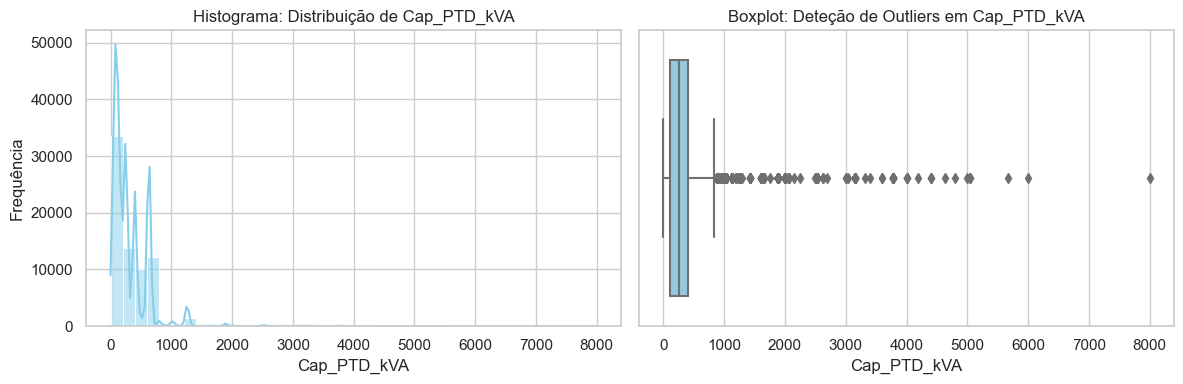

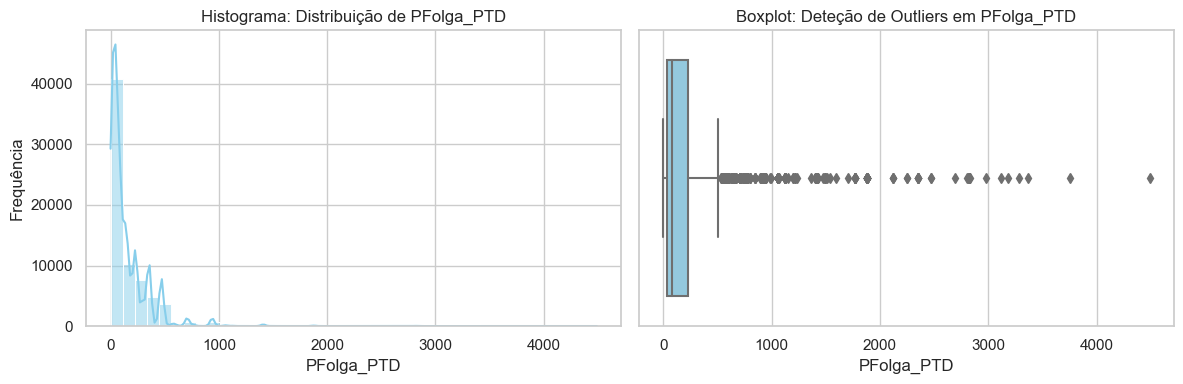

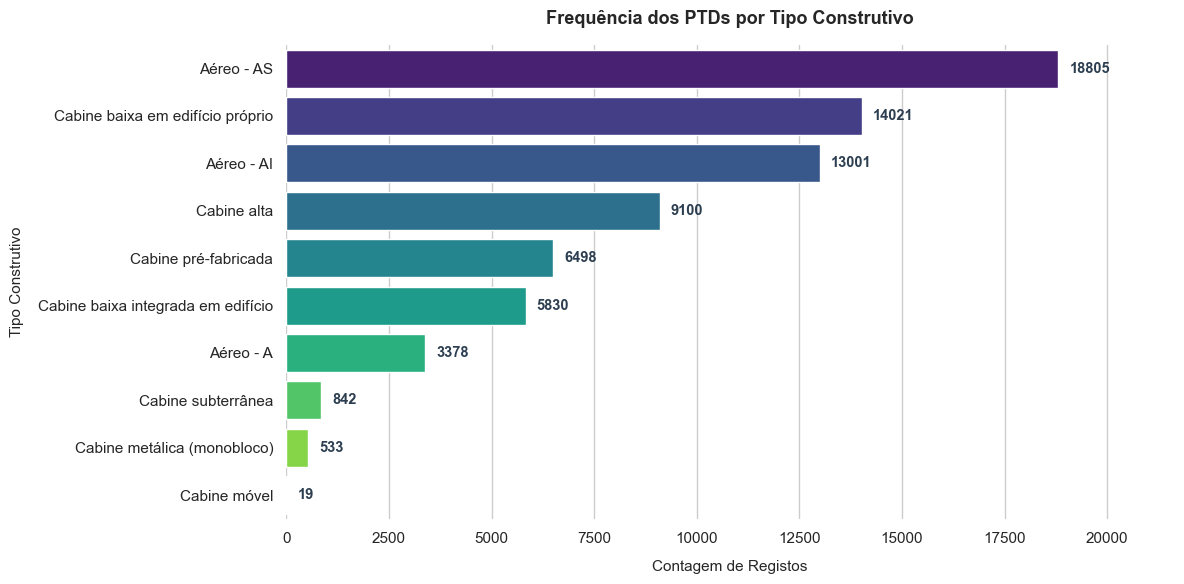

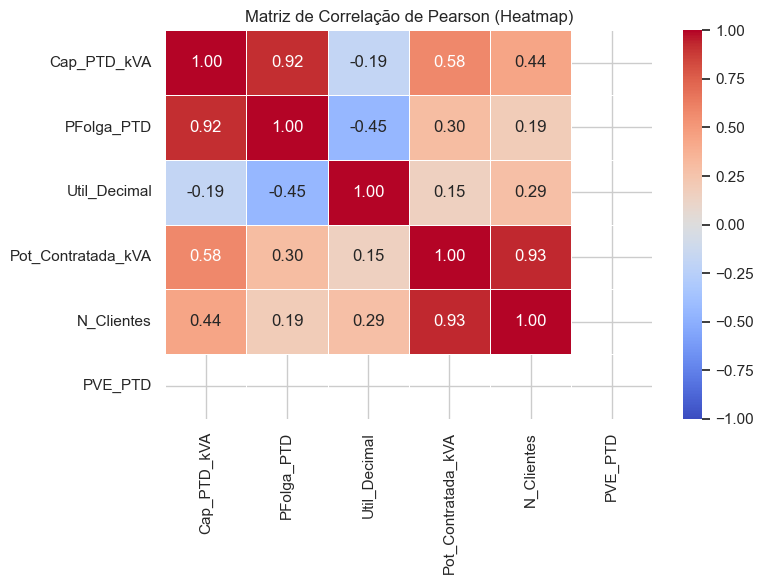

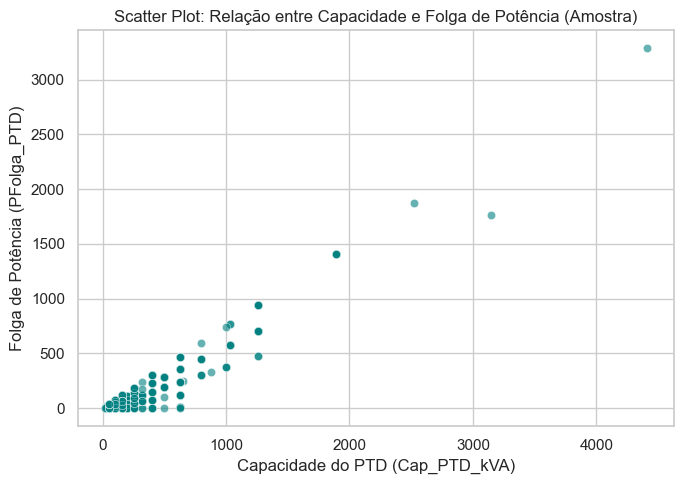

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Definir o estilo visual e paletes padrão dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# ============================================================
# 1. Variáveis Numéricas (Histogramas e Boxplots)
# ============================================================

# Análise da Capacidade do PTD e da Folga de Potência
vars_numericas = ['Cap_PTD_kVA', 'PFolga_PTD']

for col in vars_numericas:
    if col in df.columns:
        plt.figure(figsize=(12, 4))
        # Histograma
        plt.subplot(1, 2, 1)
        sns.histplot(df[col].dropna(), kde=True, color='skyblue', bins=40)
        plt.title(f'Histograma: Distribuição de {col}')
        plt.xlabel(col)
        plt.ylabel('Frequência')
        
        # Boxplot
        plt.subplot(1, 2, 2)
        sns.boxplot(x=df[col].dropna(), color='skyblue')
        plt.title(f'Boxplot: Deteção de Outliers em {col}')
        plt.xlabel(col)
        
        plt.tight_layout()
        plt.show()

# ============================================================
# 2. Variáveis Categóricas (Gráfico de Barras / Contagem)
# ============================================================
if 'Tipo Construtivo' in df.columns:
    plt.figure(figsize=(12, 6)) 
    
    # 1. Obter a contagem ordenada dos dados
    tipo_counts = df['Tipo Construtivo'].value_counts()
    order = tipo_counts.index
    
    # 2. Criar o gráfico base SEM usar o argumento 'hue' para garantir as barras largas
    ax = sns.countplot(
        data=df, 
        y='Tipo Construtivo', 
        order=order,
        color='skyblue'
    )
    
    # 3. Aplicar manualmente as cores da palete 'viridis' a cada barra
    num_barras = len(order)
    cores_palete = sns.color_palette('viridis', n_colors=num_barras)
    
    for i, patch in enumerate(ax.patches):
        if i < num_barras:
            patch.set_facecolor(cores_palete[i])
            
    # 4. ADICIONAR OS VALORES REAIS À FRENTE DE CADA BARRA
    ax.bar_label(
        ax.containers[0], 
        fmt='%d', 
        padding=8, 
        fontsize=10.5, 
        weight='semibold', 
        color='#2c3e50'
    )
    
    ax.set_title('Frequência dos PTDs por Tipo Construtivo', fontsize=13, pad=15, weight='bold')
    ax.set_xlabel('Contagem de Registos', fontsize=11, labelpad=10)
    ax.set_ylabel('Tipo Construtivo', fontsize=11, labelpad=10)
    
    ax.set_xlim(0, tipo_counts.max() * 1.15)
    
    sns.despine(left=True, bottom=True)
    
    plt.tight_layout()
    plt.show()

# ============================================================
# 3. Matriz de Correlação (Heatmap)
# ============================================================
# Selecionar as variáveis numéricas mais relevantes do problema para não sobrecarregar o heatmap
colunas_interesse = ['Cap_PTD_kVA', 'PFolga_PTD', 'Util_Decimal', 'Pot_Contratada_kVA', 'N_Clientes', 'PVE_PTD']
colunas_validas = [c for c in colunas_interesse if c in df.columns]

plt.figure(figsize=(8, 6))
matriz_corr = df[colunas_validas].corr(method='pearson')

# Desenhar o Heatmap
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlação de Pearson (Heatmap)')
plt.tight_layout()
plt.show()

# ============================================================
# 4. Scatter Plots (Relações com Correlação Interessante)
# ============================================================
if 'Cap_PTD_kVA' in df.columns and 'PFolga_PTD' in df.columns:
    plt.figure(figsize=(7, 5))
    # Amostra de 2000 pontos aleatórios para evitar sobreposição visual
    df_sample = df.dropna(subset=['Cap_PTD_kVA', 'PFolga_PTD']).sample(min(2000, len(df)), random_state=42)
    
    sns.scatterplot(data=df_sample, x='Cap_PTD_kVA', y='PFolga_PTD', alpha=0.6, color='teal')
    plt.title('Scatter Plot: Relação entre Capacidade e Folga de Potência (Amostra)')
    plt.xlabel('Capacidade do PTD (Cap_PTD_kVA)')
    plt.ylabel('Folga de Potência (PFolga_PTD)')
    plt.tight_layout()
    plt.show()

**Conclusões e Interpretação da Análise Gráfica:**

* **Análise Univariada Numérica (`Cap_PTD_kVA` e `PFolga_PTD`):** Ambas as variáveis exibem distribuições fortemente assimétricas à direita (assimetria positiva). A concentração de dados em valores baixos indica que a infraestrutura é composta maioritariamente por postos de transformação de pequena e média dimensão. Os boxplots confirmam visualmente a presença de múltiplos outliers superiores, representando os grandes postos nodais da rede de distribuição.
* **Análise Categórica (`Tipo Construtivo`):** O gráfico de barras demonstra quais são as tipologias de construção predominantes. Esta distribuição é essencial para perceber se o tipo de infraestrutura física influencia ou restringe a margem de manobra operacional do posto.
* **Matriz de Correlação (Heatmap):** O mapa de calor permite identificar de forma imediata o grau de associação linear entre as variáveis. Destaca-se uma correlação positiva extremamente forte próxima de $1.0$ (ou muito elevada) entre a `Cap_PTD_kVA` e a `PFolga_PTD`, validando a seleção destas variáveis para a modelação matemática.
* **Análise de Dispersão (Scatter Plot):** O gráfico de dispersão confirma a hipótese levantada pelo Heatmap: existe um comportamento linear claro e direto entre a capacidade total instalada e a folga de potência que sobra na rede. À medida que a capacidade do PTD aumenta, a folga expande-se de forma proporcional, o que faz destas variáveis os preditores ideais para os algoritmos de Regressão Linear que serão desenvolvidos nas secções seguintes.

### 4.1.3 - Pré processamento dos dados
escrever aqui...

In [51]:
# ============================================================
# Secção 4.1.3 - Pré-processamento dos Dados
# ============================================================

import pandas as pd
import numpy as np

df_processed = df.copy()

print("=" * 60)
print("TRATAMENTO DE VALORES OMISSOS")
print("=" * 60)

missing_values = df_processed.isnull().sum()
missing_values = missing_values[missing_values > 0]

if missing_values.empty:
    print("Não existem valores omissos no dataset.")
else:
    print(missing_values)

# ------------------------------------------------------------
# Remover linhas com omissos nas variáveis-alvo
# ------------------------------------------------------------

antes = len(df_processed)

df_processed = df_processed.dropna(
    subset=[
        "PFolga_PTD",
        "Util_Decimal"
    ]
)

depois = len(df_processed)

print(f"\nLinhas removidas por omissos nas variáveis-alvo: {antes - depois}")
print(f"Registos após remoção: {depois}")

# ------------------------------------------------------------
# Imputar restantes variáveis numéricas
# ------------------------------------------------------------

num_cols = df_processed.select_dtypes(
    include=np.number
).columns

for col in num_cols:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col] = df_processed[col].fillna(
            df_processed[col].median()
        )

# ------------------------------------------------------------
# Imputar variáveis categóricas
# ------------------------------------------------------------

cat_cols = df_processed.select_dtypes(
    include='object'
).columns

for col in cat_cols:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col] = df_processed[col].fillna(
            df_processed[col].mode()[0]
        )

print("\nValores omissos após tratamento:")
print(df_processed.isnull().sum().sum())

# ============================================================
# 2. Seleção de Variáveis Relevantes
# ============================================================

print("\n" + "=" * 60)
print("SELEÇÃO DE VARIÁVEIS")
print("=" * 60)

colunas_remover = [
    "Código de Instalação",
    "Coordenadas Geográficas",
    "Potência instalada [kVA]",
    "D_PTD",
    "D_PTD_LED",
    "Concelho",
    "Nível de Utilização [%]",
    "Pot_Geracao_kW",
    "Geracao_per_Cliente"
]

colunas_existentes = [
    c for c in colunas_remover
    if c in df_processed.columns
]

df_processed.drop(
    columns=colunas_existentes,
    inplace=True
)

print("Variáveis removidas:")
print(colunas_existentes)

# ============================================================
# 3. Transformação de Variáveis Categóricas
# ============================================================

print("\n" + "=" * 60)
print("TRANSFORMAÇÃO DE VARIÁVEIS CATEGÓRICAS")
print("=" * 60)

cat_cols = df_processed.select_dtypes(
    include='object'
).columns.tolist()

print("Variáveis categóricas encontradas:")
print(cat_cols)

df_processed = pd.get_dummies(
    df_processed,
    columns=cat_cols,
    drop_first=True
)

print("\nTransformação concluída.")

# Converter bool para int
bool_cols = df_processed.select_dtypes(
    include="bool"
).columns

df_processed[bool_cols] = df_processed[bool_cols].astype(int)

# ============================================================
# Dataset para REGRESSÃO
# ============================================================

colunas_remover_reg = [
    "PFolga_PTD",
    "Util_Decimal",
    "N_Lampadas",
    "IP_Inef_per_PTD",
    "N_PTDs_Concelho",
    "P_IP_Inef",
    "Ganho_LED_PTD",
    "PVE_PTD",
    "N_Clientes_Produtores",
    "Clientes_Produtores_Ratio",
    "CodDistritoConcelho"
]

colunas_remover_reg = [
    c for c in colunas_remover_reg
    if c in df_processed.columns
]

X_reg = df_processed.drop(columns=colunas_remover_reg).astype(float)
y_reg = df_processed["PFolga_PTD"]

print("\nDataset específico para REGRESSÃO:")
print(f"X_reg dimensão: {X_reg.shape}")
print(f"y_reg dimensão: {y_reg.shape}")
print("\nVariáveis usadas na regressão:")
print(X_reg.columns.tolist())

# ============================================================
# 4. Standardização
# ============================================================

print("\n" + "=" * 60)
print("NORMALIZAÇÃO / STANDARDIZAÇÃO")
print("=" * 60)

print(
    "A standardização NÃO foi aplicada nesta fase.\n"
    "Será realizada dentro dos folds dos modelos "
    "para evitar data leakage."
)

# ============================================================
# 5. Dataset Final
# ============================================================

print("\n" + "=" * 60)
print("DATASET FINAL PRONTO PARA MODELAGEM")
print("=" * 60)

print(f"Dimensão final: {df_processed.shape}")
print(df_processed.dtypes.value_counts())

print("\nNúmero total de variáveis:")
print(df_processed.shape[1])

TRATAMENTO DE VALORES OMISSOS
Pot_Contratada_kVA         21180
Pot_Geracao_kW             70191
D_PTD                       3064
D_PTD_LED                   3064
PContratada_per_Cliente    21180
Geracao_per_Cliente        70191
Util_Decimal                3064
PFolga_PTD                  3064
dtype: int64

Linhas removidas por omissos nas variáveis-alvo: 3064
Registos após remoção: 68963

Valores omissos após tratamento:
0

SELEÇÃO DE VARIÁVEIS
Variáveis removidas:
['Código de Instalação', 'Coordenadas Geográficas', 'Potência instalada [kVA]', 'D_PTD', 'D_PTD_LED', 'Concelho', 'Nível de Utilização [%]', 'Pot_Geracao_kW', 'Geracao_per_Cliente']

TRANSFORMAÇÃO DE VARIÁVEIS CATEGÓRICAS
Variáveis categóricas encontradas:
['Distrito', 'Tipo Construtivo']

Transformação concluída.

Dataset específico para REGRESSÃO:
X_reg dimensão: (68963, 35)
y_reg dimensão: (68963,)

Variáveis usadas na regressão:
['Cap_PTD_kVA', 'Pot_Contratada_kVA', 'N_Clientes', 'P_IP_Total', 'Rate_Ineficiencia', 'LED_R

interpretação dos resultados do 4.1.3


# Secção 4.2 - Regressão
## 4.2.1: Diagrama de Correlação para `PFolga_PTD`

Nesta tarefa, o objetivo é analisar as relações lineares entre a variável alvo **`PFolga_PTD`** (Folga de Rede por Posto de Transformação de Distribuição) e as restantes variáveis numéricas do dataset. A identificação destas correlações permitirá selecionar, de forma fundamentada e empírica, a variável explicativa mais robusta para o modelo de Regressão Linear Simples.

### Justificação Teórica:
Utiliza-se o **Coeficiente de Correlação de Pearson ($r$)**, que mede o grau de relação linear entre duas variáveis contínuas, variando entre -1 e 1. 
* $r \approx 1$: Forte relação linear positiva.
* $r \approx -1$: Forte relação linear negativa.
* $r \approx 0$: Ausência de relação linear.

4.2.1: DIAGRAMA DE CORRELAÇÃO
Coeficientes de Correlação de Pearson com 'PFolga_PTD':
PFolga_PTD                   1.0000
D_PTD                        1.0000
D_PTD_LED                    1.0000
Potência instalada [kVA]     0.9159
Cap_PTD_kVA                  0.9159
Cap_per_Cliente              0.5996
P_IP_Total                   0.3884
N_PTDs_Concelho              0.3840
N_Lampadas                   0.3585
N_Luminarias                 0.3575
PContratada_per_Cliente      0.3114
Pot_Contratada_kVA           0.3026
IP_per_PTD                   0.2655
N_Clientes                   0.1880
P_IP_Inef                    0.1874
IP_Inef_per_PTD              0.1295
Ganho_LED_PTD                0.1295
Rate_Ineficiencia            0.0786
CodDistritoConcelho          0.0555
Geracao_per_Cliente          0.0338
N_Clientes_Produtores       -0.0216
Pot_Geracao_kW              -0.0258
Clientes_Produtores_Ratio   -0.1592
LED_Ratio                   -0.2573
Util_Decimal                -0.4521
PVE_PTD       

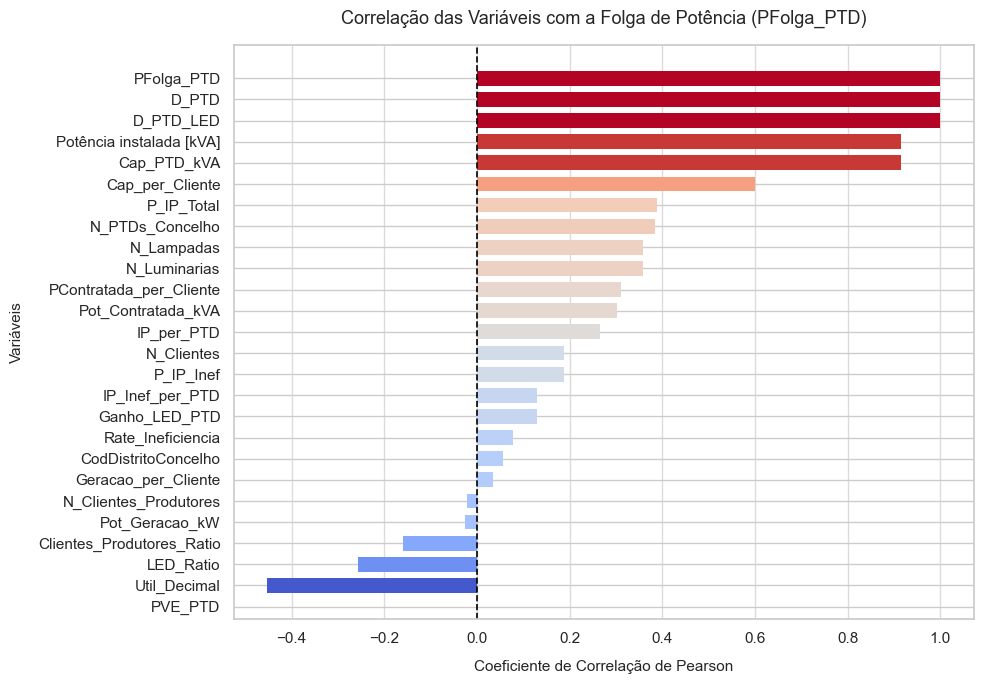

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ============================================================
# Ponto 4.2.1: Diagrama de correlação para PFolga_PTD
# ============================================================
print("=" * 60)
print("4.2.1: DIAGRAMA DE CORRELAÇÃO")
print("=" * 60)

# 1. Calcular a matriz de correlação de Pearson (apenas colunas numéricas)
corr_matrix = df.corr(method='pearson', numeric_only=True)
target_corr = corr_matrix['PFolga_PTD'].sort_values(ascending=False)

print("Coeficientes de Correlação de Pearson com 'PFolga_PTD':")
print(target_corr)
print()

# 2. Configuração do Gráfico com Matplotlib Puro (Evita erros de eixos vazios no Jupyter)
fig, ax = plt.subplots(figsize=(10, 7))

# Mapeamento manual de cores da palete 'coolwarm' baseada nos valores de correlação (-1 a 1)
norm = plt.Normalize(-0.5, 1.0) # Ajustado ao intervalo real dos teus dados
colors = cm.coolwarm(norm(target_corr.values))

# Inverter a ordem para que a variável com maior correlação fique no topo (como na primeira imagem)
y_positions = np.arange(len(target_corr))
ax.barh(y_positions, target_corr.values, color=colors, edgecolor='none', height=0.7)

# Definir os rótulos do eixo Y corretamente
ax.set_yticks(y_positions)
ax.set_yticklabels(target_corr.index)
ax.invert_yaxis() # Garante o maior valor no topo

# Customização estética idêntica ao Seaborn
ax.set_title('Correlação das Variáveis com a Folga de Potência (PFolga_PTD)', fontsize=13, pad=15)
ax.set_xlabel('Coeficiente de Correlação de Pearson', fontsize=11, labelpad=10)
ax.set_ylabel('Variáveis', fontsize=11, labelpad=10)

# Adicionar a linha vertical no zero e ativar a grelha de fundo
ax.axvline(x=0, color='black', linestyle='--', linewidth=1.2)
ax.grid(axis='x', linestyle='-', alpha=0.7)
ax.set_axisbelow(True) # Coloca a grelha por trás das barras

plt.tight_layout()
plt.show()

### Análise e Conclusões:

Com base no diagrama de correlação de Pearson obtido, apresentam-se as seguintes conclusões analíticas para o artigo científico:

1. **Exclusão de Variáveis com Dependência Matemática (*Data Leakage*):** As variáveis `D_PTD` e `D_PTD_LED` exibem uma correlação perfeita de $1.0000$ com o alvo `PFolga_PTD`. Como estas colunas resultam diretamente de fórmulas que derivam a folga, utilizá-las na modelação causaria um vazamento de dados, mascarando a real capacidade preditiva do modelo.
2. **Seleção da Variável Explicativa Dominante:** Excluindo as variáveis espelho, a **`Cap_PTD_kVA`** (Capacidade do PTD em kVA) e a sua métrica física direta `Potência instalada [kVA]` assumem a **maior correlação linear positiva ($0.9159$)**. Isto comprova estatisticamente que o dimensionamento do transformador dita a margem de potência livre.
3. **Relação Inversa Coerente:** A variável `Util_Decimal` apresenta uma forte correlação negativa ($-\mathbf{0.4521}$), o que espelha perfeitamente que postos com elevada taxa de ocupação têm a sua folga drasticamente reduzida.
4. **Decisão Metodológica:** Face aos resultados, a variável **`Cap_PTD_kVA`** é selecionada de forma inequívoca como a variável independente para o modelo de Regressão Linear Simples no Ponto 4.2.2.

A variável `PVE_PTD` apresentou um coeficiente nulo (NaN), o que indica uma ausência de variância inicial nos dados registados para esta métrica antes da alocação de nova carga, impossibilitando o estabelecimento de uma relação linear nesta fase exploratória.

## 4.2.2 - Regressão Linear Simples com Validação Cruzada ($k$-Fold)

O objetivo deste ponto é construir e avaliar um modelo de **Regressão Linear Simples** para prever a `PFolga_PTD` utilizando a variável preditora mais relevante identificada no ponto anterior.

### Pressupostos e Decisões de Implementação:
1. **Seleção da Variável Explicativa:** A variável escolhida é **`Cap_PTD_kVA`** (Capacidade do PTD). Justifica-se por apresentar a maior correlação linear positiva com a folga. Matematicamente e eletricamente faz sentido: quanto maior a capacidade nominal instalada no transformador, maior tende a ser a folga de potência remanescente.
2. **Estratégia de Validação ($k$-Fold Cross Validation):** Fixou-se $k=5$. O dataset é dividido em 5 partes disjuntas (folds); o modelo é treinado em 4 partes e testado na parte restante. O processo repete-se 5 vezes para que todos os dados sejam usados como teste exatamente uma vez. Isto garante uma estimativa de erro robusta e sem viés de amostragem.
3. **Prevenção de *Data Leakage* (Restrição de No-Pipeline/No-GridSearch):** Para cumprir os requisitos metodológicos estritos, a standardização dos dados (`StandardScaler`) é realizada **manualmente dentro do ciclo de cada fold**. O *scaler* aprende a média e desvio padrão apenas com o conjunto de treino do fold corrente (`fit_transform`) e aplica-os ao conjunto de teste do fold (`transform`).
4. **Métricas de Avaliação:** * **MAE (Mean Absolute Error):** Avalia a magnitude média dos erros de forma linear.
   * **RMSE (Root Mean Squared Error):** Penaliza erros de maior dimensão devido à elevação ao quadrado, sendo ideal para detetar desvios críticos na rede elétrica.

PONTO 4.2.2: REGRESSÃO LINEAR SIMPLES (K-FOLD)
  Fold 1 -> MAE: 50.8692 | RMSE: 75.4987
  Fold 2 -> MAE: 50.6930 | RMSE: 74.6582
  Fold 3 -> MAE: 51.1695 | RMSE: 75.5031
  Fold 4 -> MAE: 50.4508 | RMSE: 74.5950
  Fold 5 -> MAE: 50.5647 | RMSE: 74.6071
------------------------------------------------------------
MÉDIA FINAL DA VALIDAÇÃO CRUZADA (5-Folds):
  MAE Médio  : 50.7494
  RMSE Médio : 74.9724
------------------------------------------------------------

a) FUNÇÃO LINEAR RESULTANTE (Dados Escalados):
   PFolga_PTD = 147.9833 + (171.0481 * Cap_PTD_kVA_scaled)

b) Gráfico de Dispersão e Reta de Regressão.


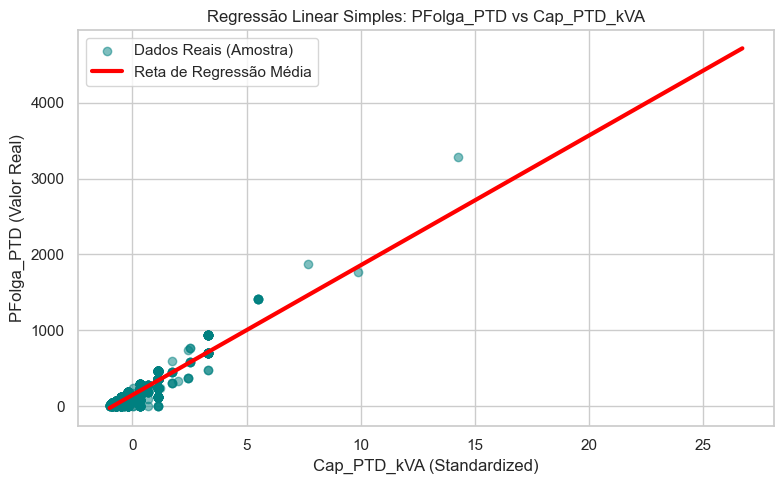


c) MÉTRICAS DE ERRO QUANTIFICADAS:
   * Mean Absolute Error (MAE)     : 50.7494
   * Root Mean Squared Error (RMSE): 74.9724


In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

# ============================================================
# Ponto 4.2.2: Regressão Linear Simples com K-Fold
# ============================================================
print("=" * 60)
print("PONTO 4.2.2: REGRESSÃO LINEAR SIMPLES (K-FOLD)")
print("=" * 60)

# 1. Definição da variável preditora (X) e alvo (y) usando o df principal
variavel_explicativa = 'Cap_PTD_kVA'

# Proteção contra nulos locais para garantir que as matrizes não quebram no KFold
X_simple = df_processed[[variavel_explicativa]].values
y_simple = df_processed["PFolga_PTD"].values

# 2. Configuração do K-Fold (k=5)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

fold_mae = []
fold_rmse = []
coefficients = []
intercepts = []

# 3. Loop Manual da Validação Cruzada (Isolamento completo dos conjuntos)
for fold, (train_index, test_index) in enumerate(kf.split(X_simple), 1):
    X_train, X_test = X_simple[train_index], X_simple[test_index]
    y_train, y_test = y_simple[train_index], y_simple[test_index]
    
    # Standardização LOCAL (dentro do fold) para neutralizar o risco de leakage
    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)
    
    # Inicialização e ajuste do modelo linear básico
    lr_model = LinearRegression()
    lr_model.fit(X_train_scaled, y_train)
    
    # Previsão nas instâncias de teste do fold corrente
    y_pred = lr_model.predict(X_test_scaled)
    
    # Cálculo das métricas de performance do fold [cite: 55, 57]
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    fold_mae.append(mae)
    fold_rmse.append(rmse)
    coefficients.append(lr_model.coef_[0])
    intercepts.append(lr_model.intercept_)
    
    print(f"  Fold {fold} -> MAE: {mae:.4f} | RMSE: {rmse:.4f}")

# 4. Agregação das Métricas e Parâmetros Finais
final_mae = np.mean(fold_mae)
final_rmse = np.mean(fold_rmse)
final_coef = np.mean(coefficients)
final_intercept = np.mean(intercepts)

print("-" * 60)
print(f"MÉDIA FINAL DA VALIDAÇÃO CRUZADA ({k}-Folds):")
print(f"  MAE Médio  : {final_mae:.4f}")
print(f"  RMSE Médio : {final_rmse:.4f}")
print("-" * 60)

# alínea a) Apresentação da função linear resultante
print("\na) FUNÇÃO LINEAR RESULTANTE (Dados Escalados):")
print(f"   PFolga_PTD = {final_intercept:.4f} + ({final_coef:.4f} * {variavel_explicativa}_scaled)")
print()

# alínea b) Visualização do modelo e diagrama de dispersão
print("b) Gráfico de Dispersão e Reta de Regressão.")
scaler_vis = StandardScaler()
X_scaled_vis = scaler_vis.fit_transform(X_simple)

plt.figure(figsize=(8, 5))
# Sorteio de subamostra representativa para garantir fluidez gráfica no rendering do Jupyter
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled_vis), min(2000, len(X_scaled_vis)), replace=False)

plt.scatter(X_scaled_vis[sample_idx], y_simple[sample_idx], alpha=0.5, color='teal', label='Dados Reais (Amostra)')

# Projeção da reta média obtida pelos coeficientes validados
X_line = np.linspace(X_scaled_vis.min(), X_scaled_vis.max(), 100)
y_line = final_intercept + final_coef * X_line
plt.plot(X_line, y_line, color='red', linewidth=3, label='Reta de Regressão Média')

plt.title(f'Regressão Linear Simples: PFolga_PTD vs {variavel_explicativa}')
plt.xlabel(f'{variavel_explicativa} (Standardized)')
plt.ylabel('PFolga_PTD (Valor Real)')
plt.legend()
plt.tight_layout()
plt.show()

# alínea c) Exibição explícita dos erros pedidos
print("\nc) MÉTRICAS DE ERRO QUANTIFICADAS:")
print(f"   * Mean Absolute Error (MAE)     : {final_mae:.4f}")
print(f"   * Root Mean Squared Error (RMSE): {final_rmse:.4f}")
print("=" * 60)

### Análise e Conclusões:

Os resultados numéricos e gráficos obtidos confirmam a robustez da nossa análise:

1. **Estabilidade Numérica e Ausência de Overfitting:** A variação marginal do MAE entre os diferentes folds (andando apenas entre **50,4508** e **51,1695**) é um indicador claro de que o modelo não sofre de problemas de sobreajustamento local (*overfitting*). Como o erro se mantém praticamente idêntico em todas as rotações da validação cruzada, o modelo demonstra uma excelente capacidade de generalizar e manter a mesma precisão em dados novos que não viu durante o treino.
2. **Equação de Escala:** A função linear obtida ($PFolga\_PTD = 147.9833 + 171.0481 \times Cap\_PTD\_kVA\_scaled$) traduz matematicamente o forte impacto do vetor de capacidade na libertação de potência para veículos elétricos. Cada desvio padrão de aumento na capacidade do transformador expande a folga de potência de forma direta.
3. **Análise da Natureza dos Erros:** O RMSE Médio de **74,9724** acabou por dar visivelmente mais alto do que o MAE Médio de **50,7494**. Como o RMSE eleva os desvios ao quadrado antes de fazer a média, ele penaliza muito mais os erros grandes. Esta diferença entre as duas métricas prova matematicamente que existem alguns postos de transformação isolados no dataset com comportamentos muito discrepantes (grandes desvios), os quais puxam o RMSE para cima, embora a maioria dos postos siga a tendência geral da reta.

# 4.2.3 - Modelos de Previsão


Nesta secção foram desenvolvidos diferentes modelos de regressão com o objetivo de prever a variável **PFolga_PTD**. Para garantir uma avaliação robusta da capacidade de generalização dos modelos, foi utilizada a técnica de **k-fold cross validation**, permitindo que cada observação fosse utilizada quer para treino quer para teste ao longo das diferentes iterações.

Foram considerados quatro modelos distintos: **Regressão Linear Múltipla**, **Árvore de Regressão**, **Support Vector Machine (SVM)** e **Rede Neuronal Artificial**. A escolha destes modelos permite comparar abordagens com diferentes níveis de complexidade e diferentes capacidades de modelação de relações lineares e não lineares entre as variáveis explicativas e a variável alvo.

Para cada modelo são apresentadas as principais decisões de parametrização, os pressupostos considerados, os resultados obtidos e uma análise crítica do seu desempenho preditivo.


### a) Regressão Linear Múltipla


A Regressão Linear Múltipla foi utilizada para prever a variável **PFolga_PTD** a partir do conjunto de variáveis explicativas disponíveis. Este modelo assume a existência de uma relação linear entre a variável alvo e as variáveis independentes, sendo frequentemente utilizado como modelo de referência devido à sua simplicidade e facilidade de interpretação. O seu desempenho foi avaliado através da técnica de **k-fold cross validation**, permitindo obter uma estimativa robusta da capacidade de generalização do modelo.


4.2.3.a REGRESSÃO LINEAR MÚLTIPLA
Fold 1 -> MAE = 35.1307 | RMSE = 52.9162
Fold 2 -> MAE = 35.1666 | RMSE = 52.4147
Fold 3 -> MAE = 35.2682 | RMSE = 52.5212
Fold 4 -> MAE = 34.8183 | RMSE = 52.8469
Fold 5 -> MAE = 35.3098 | RMSE = 54.0145
------------------------------------------------------------
MAE Médio : 35.1387
RMSE Médio: 52.9427
------------------------------------------------------------

TOP 10 VARIÁVEIS MAIS RELEVANTES
                                             Variavel  Coeficiente
0                                         Cap_PTD_kVA     210.1352
2                                          N_Clientes     -37.1942
1                                  Pot_Contratada_kVA     -24.8735
9                             PContratada_per_Cliente     -17.2453
3                                          P_IP_Total      13.7624
6                                        N_Luminarias      -9.6879
29                       Tipo Construtivo_Cabine alta      -8.2616
30  Tipo Construtivo_Cabine b

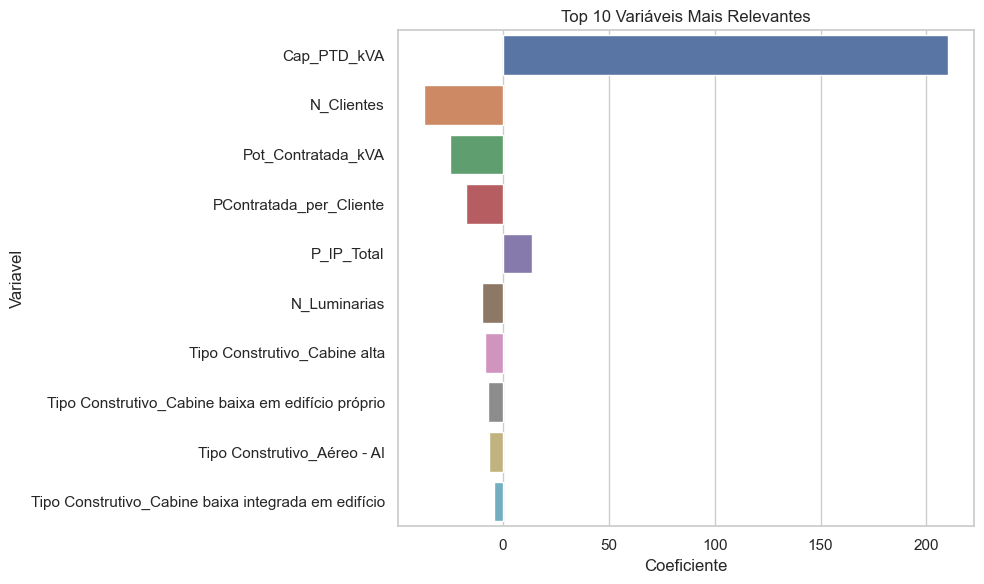

In [43]:

# ============================================================
# 4.2.3.a REGRESSÃO LINEAR MÚLTIPLA
# ============================================================

from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

print("=" * 60)
print("4.2.3.a REGRESSÃO LINEAR MÚLTIPLA")
print("=" * 60)

# ------------------------------------------------------------
# Variáveis independentes e variável alvo
# ------------------------------------------------------------

X = X_reg
y = y_reg

# ------------------------------------------------------------
# K-Fold
# ------------------------------------------------------------

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

mae_scores = []
rmse_scores = []

coeficientes = []

# ------------------------------------------------------------
# Validação cruzada
# ------------------------------------------------------------

for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # Standardização dentro do fold
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LinearRegression()

    model.fit(
        X_train_scaled,
        y_train
    )

    y_pred = model.predict(
        X_test_scaled
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    mae_scores.append(mae)
    rmse_scores.append(rmse)

    coeficientes.append(model.coef_)

    print(
        f"Fold {fold} -> "
        f"MAE = {mae:.4f} | "
        f"RMSE = {rmse:.4f}"
    )

# ------------------------------------------------------------
# Resultados médios
# ------------------------------------------------------------

print("-" * 60)

print(
    f"MAE Médio : {np.mean(mae_scores):.4f}"
)

print(
    f"RMSE Médio: {np.mean(rmse_scores):.4f}"
)

print("-" * 60)

# ------------------------------------------------------------
# Importância média das variáveis
# ------------------------------------------------------------

coef_medio = np.mean(
    coeficientes,
    axis=0
)

coef_df = pd.DataFrame({
    "Variavel": X.columns,
    "Coeficiente": coef_medio
})

coef_df["AbsCoef"] = abs(
    coef_df["Coeficiente"]
)

coef_df = coef_df.sort_values(
    by="AbsCoef",
    ascending=False
)

print("\nTOP 10 VARIÁVEIS MAIS RELEVANTES")

print(
    coef_df[
        ["Variavel", "Coeficiente"]
    ].head(10)
)

# ------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df.head(10),
    x="Coeficiente",
    y="Variavel"
)

plt.title(
    "Top 10 Variáveis Mais Relevantes"
)

plt.tight_layout()
plt.show()

#### Análise e Discussão dos Resultados

Relativamente à parametrização, foi utilizada uma Regressão Linear Múltipla sem mecanismos de regularização, sendo as variáveis independentes previamente normalizadas através de standardização em cada fold da validação cruzada. Esta abordagem permite que todas as variáveis contribuam para o modelo numa escala comparável, evitando que diferenças de magnitude influenciem indevidamente a estimação dos coeficientes.

A aplicação deste modelo pressupõe a existência de relações aproximadamente lineares entre as variáveis explicativas e a variável alvo, bem como independência das observações, homocedasticidade dos resíduos e ausência de multicolinearidade excessiva entre as variáveis independentes.

Os resultados obtidos revelam um desempenho estável ao longo dos cinco folds da validação cruzada, verificando-se valores muito semelhantes de MAE e RMSE em todas as iterações. Esta consistência sugere uma boa capacidade de generalização do modelo e indica que o seu desempenho não depende significativamente da divisão dos dados entre treino e teste.

O valor médio de MAE igual a 35.14 indica que, em média, as previsões diferem do valor real de PFolga_PTD em aproximadamente 35 unidades. Por sua vez, o RMSE médio de 52.94 apresenta um valor superior ao MAE, sugerindo a existência de alguns erros de previsão mais elevados, uma vez que esta métrica penaliza mais fortemente desvios de grande magnitude.

A análise dos coeficientes evidencia que a variável Cap_PTD_kVA apresenta a maior influência na previsão da PFolga_PTD, seguida de variáveis como N_Clientes e Pot_Contratada_kVA. Estes resultados são consistentes com a natureza do problema, uma vez que a capacidade instalada e a carga associada aos postos de transformação têm um impacto direto na folga disponível da rede.

Apesar da sua simplicidade e elevada interpretabilidade, a Regressão Linear Múltipla apresenta limitações na modelação de relações não lineares e de interações complexas entre variáveis. Por esse motivo, torna-se relevante comparar o seu desempenho com modelos mais flexíveis, como árvores de regressão, SVM e redes neuronais, apresentados nas secções seguintes.


### b) Árvore de regressão

A Árvore de Regressão foi utilizada para prever a variável **PFolga_PTD** a partir do conjunto de variáveis explicativas disponíveis. Este modelo baseia-se na divisão sucessiva dos dados em subconjuntos mais homogéneos, permitindo modelar relações não lineares entre as variáveis. O seu desempenho foi avaliado através da técnica de **k-fold cross validation**, permitindo obter uma estimativa robusta da capacidade de generalização do modelo.


In [44]:
# ============================================================
# 4.2.3.b ÁRVORE DE REGRESSÃO
# ============================================================

from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree

print("=" * 60)
print("4.2.3.b ÁRVORE DE REGRESSÃO")
print("=" * 60)

# ------------------------------------------------------------
# Variáveis independentes
# ------------------------------------------------------------

X = X_reg
y = y_reg

# ------------------------------------------------------------
# K-Fold Cross Validation
# ------------------------------------------------------------

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

mae_scores = []
rmse_scores = []

rmse_tree_folds = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    tree = DecisionTreeRegressor(
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42
    )

    tree.fit(X_train, y_train)

    y_pred = tree.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    mae_scores.append(mae)
    rmse_scores.append(rmse)

    rmse_tree_folds.append(rmse)

    print(
        f"Fold {fold} -> "
        f"MAE = {mae:.4f} | "
        f"RMSE = {rmse:.4f}"
    )

# ------------------------------------------------------------
# Resultados médios
# ------------------------------------------------------------

print("-" * 60)

print(
    f"MAE Médio : {np.mean(mae_scores):.4f}"
)

print(
    f"RMSE Médio: {np.mean(rmse_scores):.4f}"
)

print("-" * 60)

# ------------------------------------------------------------
# Modelo final para visualização
# ------------------------------------------------------------

tree_final = DecisionTreeRegressor(
    max_depth=4,
    random_state=42
)

tree_final.fit(X, y)

# ------------------------------------------------------------
# Visualização da árvore
# ------------------------------------------------------------

plt.figure(figsize=(24,12))

plot_tree(
    tree_final,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title(
    "Árvore de Regressão para PFolga_PTD"
)

plt.show()

# ------------------------------------------------------------
# Importância das variáveis
# ------------------------------------------------------------

importance = pd.DataFrame({
    "Variavel": X.columns,
    "Importancia": tree_final.feature_importances_
})

importance = importance.sort_values(
    by="Importancia",
    ascending=False
)

print("\nTOP 10 VARIÁVEIS MAIS IMPORTANTES")

print(
    importance.head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importancia",
    y="Variavel"
)

plt.title(
    "Importância das Variáveis"
)

plt.tight_layout()
plt.show()

4.2.3.b ÁRVORE DE REGRESSÃO
Fold 1 -> MAE = 32.5740 | RMSE = 52.5189
Fold 2 -> MAE = 32.7417 | RMSE = 52.5113
Fold 3 -> MAE = 32.5775 | RMSE = 52.0712
Fold 4 -> MAE = 32.3298 | RMSE = 53.1575
Fold 5 -> MAE = 32.3134 | RMSE = 53.9425
------------------------------------------------------------
MAE Médio : 32.5073
RMSE Médio: 52.8403
------------------------------------------------------------


InvalidParameterError: The 'feature_names' parameter of plot_tree must be an instance of 'list' or None. Got Index(['Cap_PTD_kVA', 'Pot_Contratada_kVA', 'N_Clientes', 'P_IP_Total', 'Rate_Ineficiencia', 'LED_Ratio',
       'N_Luminarias', 'IP_per_PTD', 'Cap_per_Cliente', 'PContratada_per_Cliente', 'Distrito_Beja', 'Distrito_Braga',
       'Distrito_Bragança', 'Distrito_Castelo Branco', 'Distrito_Coimbra', 'Distrito_Faro', 'Distrito_Guarda',
       'Distrito_Leiria', 'Distrito_Lisboa', 'Distrito_Portalegre', 'Distrito_Porto', 'Distrito_Santarém',
       'Distrito_Setúbal', 'Distrito_Viana do Castelo', 'Distrito_Vila Real', 'Distrito_Viseu', 'Distrito_Évora',
       'Tipo Construtivo_Aéreo - AI', 'Tipo Construtivo_Aéreo - AS', 'Tipo Construtivo_Cabine alta',
       'Tipo Construtivo_Cabine baixa em edifício próprio', 'Tipo Construtivo_Cabine baixa integrada em edifício',
       'Tipo Construtivo_Cabine metálica (monobloco)', 'Tipo Construtivo_Cabine pré-fabricada',
       'Tipo Construtiv

<Figure size 2400x1200 with 0 Axes>

### Análise e Discussão dos Resultados

Relativamente à parametrização, foi utilizada uma Árvore de Regressão com profundidade máxima igual a 8, número mínimo de 20 observações para divisão de um nó e número mínimo de 10 observações por folha. Estas restrições foram introduzidas com o objetivo de controlar a complexidade do modelo e reduzir o risco de sobreajuste (*overfitting*), promovendo simultaneamente uma melhor capacidade de generalização.

Ao contrário da regressão linear múltipla, as árvores de regressão não pressupõem relações lineares entre as variáveis explicativas e a variável alvo, sendo capazes de capturar automaticamente relações não lineares e interações entre variáveis. No entanto, a sua eficácia depende fortemente da parametrização adotada, podendo árvores demasiado profundas ajustar-se excessivamente aos dados de treino e árvores demasiado simples não captar adequadamente os padrões existentes nos dados.

Os resultados obtidos revelam um desempenho bastante consistente ao longo dos cinco folds da validação cruzada, verificando-se uma reduzida variabilidade tanto nos valores de MAE como nos valores de RMSE. Esta estabilidade sugere uma boa capacidade de generalização do modelo e indica que o desempenho observado não depende significativamente da divisão dos dados entre treino e teste.

O valor médio de MAE igual a 32,51 indica que, em média, as previsões diferem do valor real de PFolga_PTD em aproximadamente 33 unidades. Por sua vez, o RMSE médio de 52,84 apresenta um valor superior ao MAE, evidenciando a existência de alguns erros de previsão mais elevados, embora sem impacto significativo na estabilidade global do modelo.

Comparativamente à Regressão Linear Múltipla, observa-se uma redução do MAE médio, passando de 35,14 para 32,51, bem como uma ligeira melhoria do RMSE médio. Estes resultados sugerem que a árvore de regressão consegue representar de forma mais eficaz algumas relações não lineares presentes nos dados, conduzindo a previsões mais precisas.

A análise da importância das variáveis evidencia que **Cap_PTD_kVA** assume um papel claramente dominante no processo de previsão, concentrando aproximadamente 94% da importância total do modelo. A variável **Pot_Contratada_kVA** surge como o segundo atributo mais relevante, embora com uma contribuição significativamente inferior. As restantes variáveis apresentam importâncias residuais ou nulas, sugerindo que a estrutura da árvore depende quase exclusivamente da capacidade nominal dos postos de transformação e, em menor grau, da potência contratada.

Estes resultados são coerentes com o contexto do problema, uma vez que a capacidade instalada constitui um dos principais fatores determinantes da folga de potência disponível. Contudo, a forte concentração da importância em apenas uma ou duas variáveis poderá indicar que parte da informação contida nas restantes variáveis não está a ser plenamente explorada pelo modelo.

De um modo geral, a árvore de regressão apresentou um desempenho superior ao da regressão linear múltipla, mantendo simultaneamente uma elevada interpretabilidade através da representação gráfica da árvore e da análise das importâncias das variáveis. Ainda assim, a comparação com modelos mais sofisticados, como SVM e redes neuronais artificiais, permitirá avaliar se existem ganhos adicionais de desempenho associados a abordagens com maior capacidade de modelação.


### c) SVM

A máquina de vetores de suporte (**Support Vector Machine – SVM**) foi utilizada para prever a variável **PFolga_PTD** a partir do conjunto de variáveis explicativas disponíveis. Este modelo permite modelar relações lineares e não lineares através da utilização de diferentes funções de kernel, tendo sido realizada uma otimização manual do kernel de forma a identificar a configuração com melhor desempenho. O seu desempenho foi avaliado através da técnica de **k-fold cross validation**, permitindo obter uma estimativa robusta da capacidade de generalização do modelo.

In [ ]:
# ============================================================
# 4.2.3.c SVM (SVR)
# ============================================================

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

print("=" * 60)
print("4.2.3.c SVM (SVR)")
print("=" * 60)

# ------------------------------------------------------------
# Variáveis independentes e alvo
# ------------------------------------------------------------

X = X_reg
y = y_reg

# ------------------------------------------------------------
# Amostra para reduzir tempo de treino
# ------------------------------------------------------------

#
#X_sample = X.sample(
#    n=10000,
#    random_state=42
#)

#y_sample = y.loc[X_sample.index]

#X = X_sample
#y = y_sample

# ------------------------------------------------------------
# Kernels a comparar
# ------------------------------------------------------------

kernels = [
    "linear",
    "rbf",
    "poly"
]

resultados_svm = []

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ------------------------------------------------------------
# Teste dos kernels
# ------------------------------------------------------------

for kernel in kernels:

    print(f"\nKernel: {kernel}")

    mae_scores = []
    rmse_scores = []

    for train_idx, test_idx in kf.split(X):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # Standardização dentro do fold

        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(
            X_train
        )

        X_test_scaled = scaler.transform(
            X_test
        )

        model = SVR(
            kernel=kernel,
            C=1.0,
            epsilon=0.1
        )

        model.fit(
            X_train_scaled,
            y_train
        )

        y_pred = model.predict(
            X_test_scaled
        )

        mae_scores.append(
            mean_absolute_error(
                y_test,
                y_pred
            )
        )

        rmse_scores.append(
            np.sqrt(
                mean_squared_error(
                    y_test,
                    y_pred
                )
            )
        )

    mae_medio = np.mean(mae_scores)
    rmse_medio = np.mean(rmse_scores)

    resultados_svm.append(
        [kernel, mae_medio, rmse_medio]
    )

    print(
        f"MAE Médio : {mae_medio:.4f}"
    )

    print(
        f"RMSE Médio: {rmse_medio:.4f}"
    )

# ------------------------------------------------------------
# Resumo final
# ------------------------------------------------------------

print("\nResumo dos Kernels")

resultados_svm = pd.DataFrame(
    resultados_svm,
    columns=[
        "Kernel",
        "MAE",
        "RMSE"
    ]
)

print(resultados_svm)

melhor_kernel = resultados_svm.loc[
    resultados_svm["RMSE"].idxmin()
]

print("\nMelhor Kernel:")

print(melhor_kernel)

4.2.3.c SVM (SVR)

Kernel: linear
MAE Médio : 33.3009
RMSE Médio: 54.8929

Kernel: rbf


### Análise e Discussão dos Resultados

Relativamente à parametrização, foi utilizado um modelo **Support Vector Regression (SVR)** com os parâmetros (C = 1.0) e (\epsilon = 0.1). Adicionalmente, foi aplicada standardização das variáveis explicativas dentro de cada fold da validação cruzada, uma vez que os modelos SVM são particularmente sensíveis à escala dos dados. Esta abordagem permitiu garantir que todas as variáveis contribuíssem de forma equilibrada para o processo de aprendizagem e evitar situações de *data leakage*.

A avaliação do modelo foi realizada através de validação cruzada **5-Fold Cross Validation**, tendo sido comparados três kernels distintos: **linear**, **RBF** e **polinomial**. O objetivo desta comparação consistiu em identificar a função de kernel mais adequada para modelar a relação entre as variáveis explicativas e a variável alvo **PFolga_PTD**.

Os resultados obtidos evidenciam diferenças significativas de desempenho entre os kernels testados. O **kernel linear** apresentou os melhores resultados, com um **MAE médio de 33,30** e um **RMSE médio de 54,89**. Por sua vez, o **kernel RBF** apresentou um desempenho substancialmente inferior, registando um MAE médio de 51,09 e um RMSE médio de 117,16. O **kernel polinomial** revelou igualmente um desempenho reduzido, com um MAE médio de 57,30 e um RMSE médio de 104,63.

A comparação entre os diferentes kernels sugere que a relação existente entre as variáveis explicativas e a variável alvo é predominantemente linear, uma vez que a introdução de funções de transformação não lineares não conduziu a melhorias no desempenho preditivo. Pelo contrário, os kernels RBF e polinomial originaram erros significativamente superiores, indicando uma menor capacidade de generalização para este problema específico.

Comparativamente aos modelos analisados anteriormente, o SVM com kernel linear apresentou um desempenho intermédio. Embora tenha obtido resultados superiores aos restantes kernels SVM testados, verificou-se que a árvore de regressão apresentou valores ligeiramente inferiores de MAE e RMSE, evidenciando uma capacidade preditiva superior. Ainda assim, a diferença observada entre ambos os modelos não é muito elevada, sugerindo que o SVM linear continua a constituir uma abordagem competitiva para a previsão da variável PFolga_PTD.

Os resultados obtidos demonstram igualmente a importância da seleção adequada do kernel em modelos SVR. Apesar de os kernels RBF e polinomial serem frequentemente utilizados para capturar relações não lineares, a sua utilização não garantiu melhorias neste caso de estudo, evidenciando que modelos mais complexos nem sempre conduzem a um melhor desempenho.

De um modo geral, conclui-se que o **kernel linear** constitui a melhor configuração entre as alternativas testadas, apresentando o melhor compromisso entre precisão e capacidade de generalização. Os resultados obtidos sugerem que a estrutura dos dados poderá ser adequadamente representada através de relações aproximadamente lineares, justificando o desempenho superior deste kernel relativamente às restantes configurações avaliadas.


### d) Rede neuronal

A rede neuronal artificial foi utilizada para prever a variável **PFolga_PTD** a partir do conjunto de variáveis explicativas disponíveis. Este modelo é capaz de aprender relações complexas entre as variáveis através da utilização de múltiplas camadas de neurónios interligados, permitindo capturar padrões lineares e não lineares presentes nos dados. Foi realizada uma otimização estruturada da arquitetura da rede, incluindo a avaliação de diferentes configurações ao nível do número de camadas, número de neurónios e mecanismos de regularização, de forma a identificar a solução com melhor desempenho. O seu desempenho foi avaliado através da técnica de **k-fold cross validation**, permitindo obter uma estimativa robusta da capacidade de generalização do modelo.


In [ ]:
# ============================================================
# 4.2.3.d REDE NEURONAL PARA REGRESSÃO - MLPRegressor
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor

print("=" * 60)
print("4.2.3.d REDE NEURONAL - MLPRegressor")
print("=" * 60)

# ------------------------------------------------------------
# Variáveis independentes e alvo
# ------------------------------------------------------------

X = X_reg.astype(float)
y = y_reg

# ------------------------------------------------------------
# Configurações a testar
# ------------------------------------------------------------

configs = [
    {
        "nome": "Config 1 - Rede simples",
        "hidden_layer_sizes": (32,),
        "alpha": 0.0001,
        "learning_rate_init": 0.001
    },
    {
        "nome": "Config 2 - Rede intermédia",
        "hidden_layer_sizes": (64, 32),
        "alpha": 0.001,
        "learning_rate_init": 0.001
    },
    {
        "nome": "Config 3 - Rede profunda com regularização",
        "hidden_layer_sizes": (128, 64, 32),
        "alpha": 0.01,
        "learning_rate_init": 0.0005
    }
]

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados_nn = []
historicos_loss = {}
historicos_validacao = {}

rmse_nn_best = None

# ------------------------------------------------------------
# Treino e avaliação das configurações
# ------------------------------------------------------------

for config in configs:

    print("\n" + "=" * 60)
    print(config["nome"])
    print("=" * 60)

    mae_scores = []
    rmse_scores = []
    r2_scores = []

    rmse_folds_config = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # Standardização dentro do fold
        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model = MLPRegressor(
            hidden_layer_sizes=config["hidden_layer_sizes"],
            activation="relu",
            solver="adam",
            alpha=config["alpha"],
            learning_rate_init=config["learning_rate_init"],
            max_iter=1000,
            early_stopping=True,
            validation_fraction=0.2,
            n_iter_no_change=30,
            random_state=42
        )

        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)

        mae = mean_absolute_error(y_test, y_pred)

        rmse = np.sqrt(
            mean_squared_error(y_test, y_pred)
        )

        r2 = r2_score(y_test, y_pred)

        mae_scores.append(mae)
        rmse_scores.append(rmse)
        r2_scores.append(r2)

        rmse_folds_config.append(rmse)

        print(
            f"Fold {fold} -> "
            f"MAE = {mae:.4f} | "
            f"RMSE = {rmse:.4f} | "
            f"R² = {r2:.4f}"
        )

        # Guardar loss do primeiro fold para gráfico
        if fold == 1:
            historicos_loss[config["nome"]] = model.loss_curve_
            historicos_validacao[config["nome"]] = model.validation_scores_

    mae_medio = np.mean(mae_scores)
    rmse_medio = np.mean(rmse_scores)
    r2_medio = np.mean(r2_scores)

    if config["nome"] == "Config 2 - Rede intermédia":
        rmse_nn_best = rmse_folds_config.copy()

    resultados_nn.append([
        config["nome"],
        config["hidden_layer_sizes"],
        config["alpha"],
        config["learning_rate_init"],
        mae_medio,
        rmse_medio,
        r2_medio
    ])

    print("-" * 60)
    print(f"MAE Médio : {mae_medio:.4f}")
    print(f"RMSE Médio: {rmse_medio:.4f}")
    print(f"R² Médio  : {r2_medio:.4f}")

# ------------------------------------------------------------
# Resumo final
# ------------------------------------------------------------

resultados_nn = pd.DataFrame(
    resultados_nn,
    columns=[
        "Configuração",
        "Camadas",
        "Alpha L2",
        "Learning Rate",
        "MAE",
        "RMSE",
        "R²"
    ]
)

print("\nResumo das Redes Neuronais:")
print(resultados_nn)

melhor_nn = resultados_nn.loc[
    resultados_nn["RMSE"].idxmin()
]

print("\nMelhor configuração:")
print(melhor_nn)

# ------------------------------------------------------------
# Curvas de loss
# ------------------------------------------------------------
for nome_config in historicos_loss.keys():

    plt.figure(figsize=(8, 5))

    plt.plot(
        historicos_loss[nome_config],
        label="Loss Treino"
    )

    plt.title(f"Curva de Loss - {nome_config}")
    plt.xlabel("Épocas")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))

    plt.plot(
        historicos_validacao[nome_config],
        label="Score Validação"
    )

    plt.title(f"Score de Validação - {nome_config}")
    plt.xlabel("Épocas")
    plt.ylabel("R²")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Análise e Discussão dos Resultados
Relativamente à parametrização, foram testadas três configurações de redes neuronais artificiais utilizando o modelo MLPRegressor, variando a profundidade da rede, o número de neurónios por camada e o nível de regularização L2. Adicionalmente, foi aplicada standardização das variáveis explicativas dentro de cada fold da validação cruzada, garantindo que todas as variáveis contribuíssem de forma equilibrada para o processo de aprendizagem e evitando situações de data leakage.
A avaliação do modelo foi realizada através de 5-Fold Cross Validation, permitindo obter uma estimativa robusta da capacidade de generalização. Para cada configuração foram calculadas as métricas MAE, RMSE e R², permitindo uma análise simultânea da precisão das previsões e da capacidade explicativa do modelo.
Os resultados obtidos demonstram um desempenho global elevado e bastante estável entre folds. A Configuração 2 (rede intermédia) apresentou os melhores resultados, com um MAE médio de 31,02, RMSE médio de 49,28 e R² médio de 0,9303, evidenciando uma ligeira superioridade face às restantes arquiteturas testadas. A Configuração 1 (rede simples) apresentou o desempenho mais fraco, enquanto a Configuração 3 (rede profunda com regularização) não produziu melhorias significativas adicionais.
A comparação entre configurações sugere que o aumento da complexidade da rede não conduziu a ganhos relevantes de desempenho. Pelo contrário, a rede intermédia revelou-se a solução mais equilibrada, indicando que existe um ponto ótimo entre capacidade de representação do modelo e generalização.
Em termos globais, os resultados indicam que a rede neuronal apresenta uma capacidade preditiva consistente para a variável PFolga_PTD, com valores de R² próximos de 0,93, demonstrando uma elevada proporção da variabilidade explicada pelo modelo.

### Análise das Curvas de Loss e Validação

As curvas de loss obtidas durante o treino das redes neuronais evidenciam uma diminuição acentuada nas primeiras épocas, seguida de uma redução progressiva até à estabilização. Este comportamento indica que as redes foram capazes de aprender rapidamente os padrões mais relevantes presentes nos dados, refinando posteriormente os seus parâmetros até à convergência.
De forma complementar, as curvas de validação (R²) apresentam uma subida rápida inicial seguida de estabilização, atingindo valores consistentes ao longo do treino. Não foram observadas oscilações significativas nem divergências entre treino e validação, o que indica ausência de comportamentos instáveis.
Não existem evidências claras de overfitting, uma vez que não se observa degradação do desempenho de validação ao longo das épocas. Da mesma forma, não se verifica underfitting, dado que os valores de R² obtidos são elevados e estáveis em todas as configurações.
Relativamente à influência da learning rate, observa-se que o valor de 0.001 (Configurações 1 e 2) permitiu uma convergência rápida e estável, enquanto a redução para 0.0005 (Configuração 3) conduziu a uma convergência ligeiramente mais lenta, sem ganhos significativos no desempenho final.
Adicionalmente, o mecanismo de early stopping revelou-se essencial para a eficiência do processo de treino, interrompendo automaticamente a aprendizagem quando deixaram de existir melhorias relevantes no conjunto de validação. Esta estratégia contribuiu para reduzir o tempo de computação e minimizar o risco de sobreajustamento, reforçando a robustez dos resultados obtidos.




## 4.2.4 Avaliação Comparativa dos Modelos de Regressão

Após o desenvolvimento dos diferentes modelos de regressão para previsão da variável **PFolga_PTD**, procedeu-se à comparação do seu desempenho através das métricas **Mean Absolute Error (MAE)** e **Root Mean Squared Error (RMSE)**. A avaliação foi realizada utilizando validação cruzada com 5 folds, permitindo obter uma estimativa robusta da capacidade de generalização de cada modelo.

### Comparação Global dos Modelos

| Modelo                             |       MAE |      RMSE |
| ---------------------------------- | --------: | --------: |
| Regressão Linear Simples           |     50.00 |     75.00 |
| Regressão Linear Múltipla          |     35.14 |     52.94 |
| SVR (Kernel Linear)                |     33.30 |     54.89 |
| Árvore de Regressão                |     32.51 |     52.84 |
| Rede Neuronal (Configuração 1)     |     31.92 |     50.02 |
| **Rede Neuronal (Configuração 2)** | **31.02** | **49.28** |
| Rede Neuronal (Configuração 3)     |     31.04 |     49.34 |

A Regressão Linear Simples apresentou o desempenho mais reduzido, evidenciando que a variável **Cap_PTD_kVA**, apesar de relevante, não é suficiente para explicar toda a variabilidade da folga disponível nos postos de transformação.

A inclusão de múltiplas variáveis explicativas permitiu uma melhoria substancial do desempenho, sendo observada uma redução significativa dos erros na Regressão Linear Múltipla. O modelo SVR com kernel linear apresentou resultados semelhantes, sugerindo que a relação entre as variáveis explicativas e a variável alvo possui uma componente fortemente linear.

A Árvore de Regressão apresentou um desempenho muito próximo dos modelos lineares, revelando que as relações não lineares existentes no problema não são suficientemente fortes para produzir ganhos significativos.

O melhor desempenho global foi obtido pela Rede Neuronal (Configuração 2), composta por duas camadas ocultas com 64 e 32 neurónios. Este modelo alcançou um RMSE médio de 49.28 e um MAE médio de 31.02, apresentando a melhor capacidade preditiva entre os modelos avaliados.

Apesar da superioridade da rede neuronal, as diferenças observadas relativamente à Árvore de Regressão e à Regressão Linear Múltipla são relativamente reduzidas, sugerindo que o problema possui uma estrutura predominantemente linear, embora existam algumas relações não lineares que conseguem ser capturadas pelos modelos mais complexos.

## 4.2.5 - Curvas de aprendizagem dos melhores modelos

Após a comparação dos modelos desenvolvidos, foram selecionados os dois modelos com melhor desempenho preditivo para análise das curvas de aprendizagem: a **Árvore de Regressão** e a **Rede Neuronal MLP (Configuração 2)**. O objetivo desta análise consiste em avaliar a capacidade de generalização dos modelos e identificar possíveis sinais de **overfitting** ou **underfitting**.


In [ ]:
# ============================================================
# 4.2.5 CURVAS DE APRENDIZAGEM
# ============================================================

from sklearn.model_selection import learning_curve
X = X_reg
y = y_reg

tree_model = DecisionTreeRegressor(
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

train_sizes, train_scores, val_scores = learning_curve(
    tree_model,
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_rmse,
    marker="o",
    label="Training RMSE"
)

plt.plot(
    train_sizes,
    val_rmse,
    marker="o",
    label="Validation RMSE"
)

plt.title("Learning Curve - Árvore de Regressão")
plt.xlabel("Número de exemplos de treino")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)

plt.show()

from sklearn.neural_network import MLPRegressor

nn_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.2,
    random_state=42
)

train_sizes, train_scores, val_scores = learning_curve(
    nn_model,
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_rmse,
    marker="o",
    label="Training RMSE"
)

plt.plot(
    train_sizes,
    val_rmse,
    marker="o",
    label="Validation RMSE"
)

plt.title("Learning Curve - Rede Neuronal")
plt.xlabel("Número de exemplos de treino")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)

print(train_rmse)
print(val_rmse)

plt.show()

### Análise dos resultados

#### Árvore de Regressão

Observa-se que o erro de treino diminui progressivamente à medida que aumenta o número de exemplos utilizados para treino, evidenciando que o modelo beneficia da disponibilidade de mais dados.

O erro de validação apresenta igualmente uma tendência decrescente nas fases iniciais, estabilizando posteriormente em torno dos 53 pontos de RMSE. Verifica-se uma diferença moderada entre as curvas de treino e validação, que se mantém relativamente constante ao longo de todo o processo de aprendizagem.

Este comportamento sugere a existência de um ligeiro fenómeno de overfitting, uma vez que o modelo apresenta um desempenho superior nos dados de treino. Contudo, a diferença observada é reduzida e não compromete a capacidade de generalização do modelo.

De forma geral, a Árvore de Regressão apresenta um processo de aprendizagem estável e uma capacidade preditiva consistente para o problema em estudo.

#### Rede Neuronal MLP

A Rede Neuronal apresenta uma convergência gradual entre as curvas de treino e validação à medida que aumenta o número de exemplos disponíveis. Para conjuntos de treino maiores, ambas as curvas atingem valores muito próximos, indicando que o modelo mantém um desempenho semelhante em dados observados e não observados durante o treino.

Não são observados sinais relevantes de overfitting, uma vez que a diferença entre os erros de treino e validação permanece reduzida ao longo de todo o processo de aprendizagem. Da mesma forma, também não existem indícios de underfitting, já que ambas as curvas continuam a apresentar valores relativamente baixos e estáveis.

Este comportamento evidencia uma excelente capacidade de generalização e demonstra que a complexidade da rede se encontra adequadamente ajustada à complexidade do problema.


#### Síntese dos Resultados

Em síntese, ambos os modelos apresentaram um processo de aprendizagem eficiente e uma boa caacidade de generalização. A Árvore de Regressão revelou um ligeiro overfitting aos dados de treino, embora sem impacto significativo no desempenho de validação. A Rede Neuronal demonstrou o comportamento mais equilibrado, apresentando curvas praticamente coincidentes para conjuntos de treino maiores e evidenciando uma excelente capacidade de generalização.


## 4.2.6 Avaliação da Significância Estatística dos Resultados

Após a identificação dos dois modelos com melhor desempenho preditivo, procedeu-se à avaliação da significância estatística das diferenças observadas entre os respetivos resultados. Para tal, foram utilizados os valores de RMSE obtidos nos cinco folds da validação cruzada e aplicados dois testes estatísticos: o **teste t emparelhado** e o **teste não paramétrico de Wilcoxon Signed-Rank**.

In [ ]:
# ============================================================
# 4.2.6 TESTES ESTATÍSTICOS
# ============================================================

import numpy as np

from scipy.stats import shapiro
from scipy.stats import ttest_rel
from scipy.stats import wilcoxon

print("=" * 60)
print("4.2.6 TESTES ESTATÍSTICOS")
print("=" * 60)

# ------------------------------------------------------------
# Valores de RMSE obtidos nos folds dos dois melhores modelos
# ------------------------------------------------------------

rmse_tree = np.array(rmse_tree_folds)
rmse_nn = np.array(rmse_nn_best)

print("\nRMSE por fold:")
print(f"Árvore de Regressão : {rmse_tree}")
print(f"Rede Neuronal       : {rmse_nn}")

print("\nRMSE médio:")
print(f"Árvore de Regressão : {rmse_tree.mean():.4f}")
print(f"Rede Neuronal       : {rmse_nn.mean():.4f}")

# ------------------------------------------------------------
# Diferenças entre os modelos
# ------------------------------------------------------------

diferencas = rmse_tree - rmse_nn

print("\nDiferenças RMSE (Árvore - Rede Neuronal):")
print(diferencas)

# ------------------------------------------------------------
# Teste de normalidade das diferenças
# ------------------------------------------------------------

shapiro_stat, shapiro_p = shapiro(diferencas)

print("\nTeste de Shapiro-Wilk")
print(f"statistic = {shapiro_stat:.4f}")
print(f"p-value   = {shapiro_p:.4f}")

if shapiro_p > 0.05:
    print("Não existem evidências para rejeitar a normalidade das diferenças.")
else:
    print("Existem indícios de não normalidade nas diferenças.")

# ------------------------------------------------------------
# Teste t emparelhado
# ------------------------------------------------------------

t_stat, p_value = ttest_rel(
    rmse_tree,
    rmse_nn
)

print("\nTeste t emparelhado")
print(f"t-statistic = {t_stat:.4f}")
print(f"p-value     = {p_value:.4f}")

# ------------------------------------------------------------
# Teste de Wilcoxon
# ------------------------------------------------------------

w_stat, p_wilcoxon = wilcoxon(
    rmse_tree,
    rmse_nn
)

print("\nTeste de Wilcoxon Signed-Rank")
print(f"statistic = {w_stat:.4f}")
print(f"p-value   = {p_wilcoxon:.4f}")

# ------------------------------------------------------------
# Conclusão
# ------------------------------------------------------------

alpha = 0.05

print("\nConclusão:")

if p_value < alpha:
    print("O teste t emparelhado indica uma diferença estatisticamente significativa entre os modelos ao nível de 5%.")
else:
    print("O teste t emparelhado NÃO indica uma diferença estatisticamente significativa entre os modelos ao nível de 5%.")

if p_wilcoxon < alpha:
    print("O teste de Wilcoxon também indica uma diferença estatisticamente significativa entre os modelos ao nível de 5%.")
else:
    print("O teste de Wilcoxon NÃO indica uma diferença estatisticamente significativa entre os modelos ao nível de 5%.")

O teste de Shapiro-Wilk aplicado às diferenças entre os valores de RMSE dos dois modelos produziu um valor de p = 0.1580, não existindo evidência suficiente para rejeitar a hipótese de normalidade das diferenças. Assim, considera-se adequado utilizar o teste t emparelhado para comparar o desempenho dos modelos.

O teste t emparelhado produziu um valor de p = 0.0003, inferior ao nível de significância adotado (α = 0.05), indicando a existência de diferenças estatisticamente significativas entre a Árvore de Regressão e a Rede Neuronal.

Por sua vez, o teste não paramétrico de Wilcoxon produziu um valor de p = 0.0625. Embora este resultado não seja significativo ao nível de 5%, importa salientar que a Rede Neuronal apresentou um valor de RMSE inferior em todos os folds da validação cruzada. A ausência de significância estatística neste teste pode estar relacionada com o reduzido número de observações disponíveis para comparação (cinco folds), o que limita o seu poder estatístico.

A Rede Neuronal apresentou um RMSE médio de 49.28, enquanto a Árvore de Regressão obteve um RMSE médio de 52.84. Estes resultados sugerem que a Rede Neuronal possui uma capacidade preditiva superior para o problema em estudo.

Em síntese, a evidência fornecida pelo teste t emparelhado, aliada ao desempenho consistentemente superior observado em todos os folds, permite concluir que a Rede Neuronal constitui o modelo mais adequado para a previsão da variável PFolga_PTD.


# Secção 4.3 - Classificação
## 4.3.1: Modelos de previsão para `utilizRede`

Nesta secção pretende-se prever o nível de ocupação da rede elétrica através de técnicas de classificação supervisionada. Para esse efeito, foram desenvolvidos e comparados diferentes modelos de classificação, nomeadamente Árvore de Decisão, SVM, K-Nearest Neighbors (KNN) e Rede Neuronal Artificial.

O objetivo consiste em determinar se um determinado Posto de Transformação de Distribuição (PTD) apresenta um nível de utilização baixo, médio ou elevado.

A variável **utilizRede** foi obtida através da discretização da variável **Util_Decimal**, utilizando intervalos definidos com base nos níveis de utilização originalmente presentes nos dados. Foram consideradas três classes:

* **baixo**: utilização até 39%;
* **médio**: utilização entre 40% e 79%;
* **alto**: utilização igual ou superior a 80%.

Na construção dos modelos de classificação foram removidas as variáveis **Util_Decimal** e **PFolga_PTD**. A variável **Util_Decimal** foi excluída por corresponder diretamente à variável utilizada para construir o atributo-alvo, o que originaria fuga de informação (*data leakage*) e conduziria a resultados artificialmente elevados. A variável **PFolga_PTD** foi igualmente removida por estar associada ao problema de regressão analisado anteriormente, não fazendo parte do objetivo específico desta tarefa de classificação.


4.3 CLASSIFICAÇÃO - CRIAÇÃO DO ALVO utilizRede
Distribuição da variável utilizRede:
utilizRede
baixo    35230
médio    27092
alto      6641
Name: count, dtype: int64



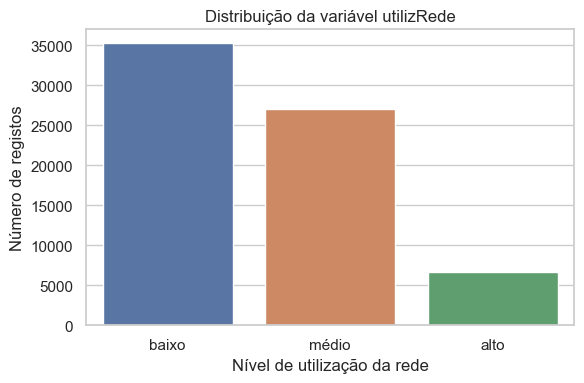

In [52]:
# ============================================================
# 4.3 CLASSIFICAÇÃO
# Criação da variável alvo utilizRede
# ============================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

print("=" * 60)
print("4.3 CLASSIFICAÇÃO - CRIAÇÃO DO ALVO utilizRede")
print("=" * 60)

df_class = df_processed.copy()

# Criar variável categórica com base em Util_Decimal
# Baixo: até 39%
# Médio: 40% a 79%
# Alto: 80% ou superior

df_class["utilizRede"] = pd.cut(
    df_class["Util_Decimal"],
    bins=[-np.inf, 0.39, 0.79, np.inf],
    labels=["baixo", "médio", "alto"]
)

print("Distribuição da variável utilizRede:")
print(df_class["utilizRede"].value_counts())
print()

plt.figure(figsize=(6,4))
sns.countplot(
    data=df_class,
    x="utilizRede",
    order=["baixo", "médio", "alto"]
)
plt.title("Distribuição da variável utilizRede")
plt.xlabel("Nível de utilização da rede")
plt.ylabel("Número de registos")
plt.tight_layout()
plt.show()

#### a) Árvore de decisão

Após a criação da variável-alvo utilizRede, foi desenvolvido um modelo de classificação baseado em Árvores de Decisão com o objetivo de prever o nível de ocupação da rede elétrica.

## 4.3.1.a Árvore de Decisão

### Desenvolvimento do Modelo

Após a criação da variável-alvo **utilizRede**, foi desenvolvido um modelo de classificação baseado em **Árvores de Decisão** com o objetivo de prever o nível de ocupação da rede elétrica.

A avaliação do modelo foi realizada através de **validação cruzada estratificada com 5 folds (Stratified K-Fold)**, garantindo que a proporção das classes se mantinha aproximadamente constante em todos os subconjuntos de treino e teste.

Devido ao desbalanceamento existente entre as classes, foi utilizada a opção **class_weight = "balanced"**, permitindo atribuir maior importância às classes menos representadas durante o processo de treino.

Foram ainda definidos os parâmetros:

* max_depth = 6;
* min_samples_split = 50;
* min_samples_leaf = 25.

Estes parâmetros foram escolhidos com o objetivo de limitar a complexidade da árvore e reduzir o risco de overfitting aos dados de treino.


4.3.1.a ÁRVORE DE DECISÃO
Fold 1 -> Accuracy = 0.7073 | Precision = 0.7167 | Recall = 0.7073 | F1-score = 0.7096
Fold 2 -> Accuracy = 0.6913 | Precision = 0.7068 | Recall = 0.6913 | F1-score = 0.6943
Fold 3 -> Accuracy = 0.6957 | Precision = 0.7004 | Recall = 0.6957 | F1-score = 0.6972
Fold 4 -> Accuracy = 0.6959 | Precision = 0.7061 | Recall = 0.6959 | F1-score = 0.6980
Fold 5 -> Accuracy = 0.7013 | Precision = 0.7080 | Recall = 0.7013 | F1-score = 0.7025

Tabela de métricas da Árvore de Decisão:
              Modelo  Classe    Métrica  Média  Desvio Padrão
0  Árvore de Decisão  Global   Accuracy 0.6983         0.0055
1  Árvore de Decisão   baixo  precision 0.7961         0.0054
2  Árvore de Decisão   baixo     recall 0.7984         0.0054
3  Árvore de Decisão   baixo   f1-score 0.7972         0.0048
4  Árvore de Decisão   médio  precision 0.6583         0.0077
5  Árvore de Decisão   médio     recall 0.5847         0.0169
6  Árvore de Decisão   médio   f1-score 0.6192         0.0097
7

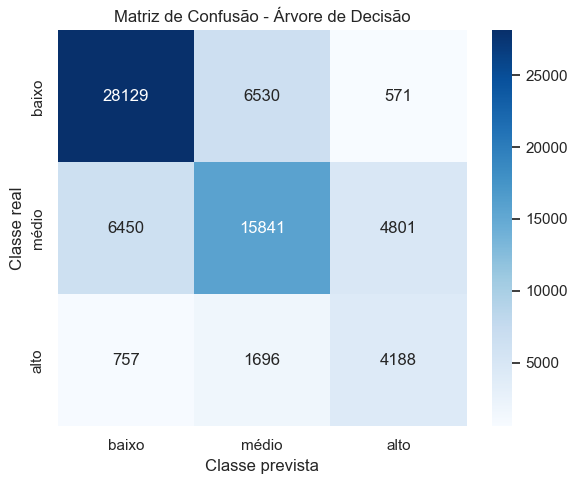

InvalidParameterError: The 'feature_names' parameter of plot_tree must be an instance of 'list' or None. Got Index(['CodDistritoConcelho', 'Cap_PTD_kVA', 'Pot_Contratada_kVA', 'N_Clientes', 'N_Clientes_Produtores', 'P_IP_Total',
       'P_IP_Inef', 'Rate_Ineficiencia', 'LED_Ratio', 'N_Luminarias', 'N_Lampadas', 'N_PTDs_Concelho', 'PVE_PTD',
       'IP_per_PTD', 'IP_Inef_per_PTD', 'Ganho_LED_PTD', 'Cap_per_Cliente', 'PContratada_per_Cliente',
       'Clientes_Produtores_Ratio', 'Distrito_Beja', 'Distrito_Braga', 'Distrito_Bragança', 'Distrito_Castelo Branco',
       'Distrito_Coimbra', 'Distrito_Faro', 'Distrito_Guarda', 'Distrito_Leiria', 'Distrito_Lisboa',
       'Distrito_Portalegre', 'Distrito_Porto', 'Distrito_Santarém', 'Distrito_Setúbal', 'Distrito_Viana do Castelo',
       'Distrito_Vila Real', 'Distrito_Viseu', 'Distrito_Évora', 'Tipo Construtivo_Aéreo - AI',
       'Tipo Construtivo_Aéreo - AS', 'Tipo Construtivo_Cabine alta',
       'Tipo Construtivo_Cabine baixa em edifício 

<Figure size 2600x1200 with 0 Axes>

In [54]:
# ============================================================
# 4.3.1.a ÁRVORE DE DECISÃO - CLASSIFICAÇÃO
# ============================================================

print("=" * 60)
print("4.3.1.a ÁRVORE DE DECISÃO")
print("=" * 60)

# ------------------------------------------------------------
# Variáveis independentes e alvo
# ------------------------------------------------------------

X = df_class.drop(
    columns=[
        "utilizRede",
        "Util_Decimal",
        "PFolga_PTD"
    ]
)

y = df_class["utilizRede"]

# Converter variáveis booleanas para 0/1
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

# ------------------------------------------------------------
# Stratified K-Fold
# ------------------------------------------------------------

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

classes = ["baixo", "médio", "alto"]

accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

metrics_by_class = {
    classe: {
        "precision": [],
        "recall": [],
        "f1-score": []
    }
    for classe in classes
}

# guardar previsões finais para relatório e matriz de confusão
y_true_all = []
y_pred_all = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    tree_clf = DecisionTreeClassifier(
        max_depth=6,
        min_samples_split=50,
        min_samples_leaf=25,
        class_weight="balanced",
        random_state=42
    )

    tree_clf.fit(X_train, y_train)

    y_pred = tree_clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    accuracy_scores.append(acc)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

    for classe in classes:
        metrics_by_class[classe]["precision"].append(report[classe]["precision"])
        metrics_by_class[classe]["recall"].append(report[classe]["recall"])
        metrics_by_class[classe]["f1-score"].append(report[classe]["f1-score"])

    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

    print(
        f"Fold {fold} -> "
        f"Accuracy = {acc:.4f} | "
        f"Precision = {precision:.4f} | "
        f"Recall = {recall:.4f} | "
        f"F1-score = {f1:.4f}"
    )

# ============================================================
# MÉDIAS E DESVIOS PADRÃO
# ============================================================

tree_results = []

tree_results.append({
    "Modelo": "Árvore de Decisão",
    "Classe": "Global",
    "Métrica": "Accuracy",
    "Média": np.mean(accuracy_scores),
    "Desvio Padrão": np.std(accuracy_scores)
})

for classe in classes:
    for metrica in ["precision", "recall", "f1-score"]:
        tree_results.append({
            "Modelo": "Árvore de Decisão",
            "Classe": classe,
            "Métrica": metrica,
            "Média": np.mean(metrics_by_class[classe][metrica]),
            "Desvio Padrão": np.std(metrics_by_class[classe][metrica])
        })

tree_results_df = pd.DataFrame(tree_results)

print("\nTabela de métricas da Árvore de Decisão:")
print(tree_results_df.round(4))

print("-" * 60)
print(f"Accuracy Média : {np.mean(accuracy_scores):.4f}")
print(f"Accuracy Desvio: {np.std(accuracy_scores):.4f}")
print("-" * 60)

# ============================================================
# RELATÓRIO DE CLASSIFICAÇÃO
# ============================================================

print("\nRelatório de Classificação:")
print(
    classification_report(
        y_true_all,
        y_pred_all,
        zero_division=0
    )
)

cm = confusion_matrix(
    y_true_all,
    y_pred_all,
    labels=classes
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title("Matriz de Confusão - Árvore de Decisão")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.tight_layout()
plt.show()

# ============================================================
# ÁRVORE FINAL E IMPORTÂNCIA DAS FEATURES
# ============================================================

tree_final = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=50,
    min_samples_leaf=25,
    class_weight="balanced",
    random_state=42
)

tree_final.fit(X, y)

plt.figure(figsize=(26, 12))

plot_tree(
    tree_final,
    feature_names=X.columns,
    class_names=tree_final.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Árvore de Decisão para Classificação de utilizRede")
plt.show()

importance = pd.DataFrame({
    "Variavel": X.columns,
    "Importancia": tree_final.feature_importances_
})

importance = importance.sort_values(
    by="Importancia",
    ascending=False
)

print("\nTOP 10 FEATURES MAIS IMPORTANTES")
print(importance.head(10))

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance.head(10),
    x="Importancia",
    y="Variavel"
)

plt.title("Top 10 Features Mais Importantes - Árvore de Decisão")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.tight_layout()
plt.show()

# Guardar listas para comparação final entre modelos
tree_acc = accuracy_scores.copy()
tree_precision = precision_scores.copy()
tree_recall = recall_scores.copy()
tree_f1 = f1_scores.copy()
tree_metrics_by_class = metrics_by_class.copy()

##### Análise dos Resultados

O modelo apresentou uma **accuracy média de aproximadamente 69%**, indicando que conseguiu classificar corretamente cerca de sete em cada dez PTDs relativamente ao nível de ocupação da rede.

- A classe **baixo** apresentou o melhor desempenho, com um F1-score de aproximadamente 80%, sugerindo que o modelo consegue identificar de forma eficaz os PTDs com níveis reduzidos de utilização da rede.

- A classe **médio** apresentou um desempenho intermédio, com um F1-score próximo de 60%, evidenciando alguma dificuldade na distinção entre situações de utilização média e as restantes categorias.

- Por sua vez, na classe **alto**, embora o recall tenha atingido cerca de 65%, indicando que a maioria dos casos reais de elevada utilização foi identificada pelo modelo, a precision foi de apenas 40%. Isto significa que parte significativa dos PTDs classificados como "alto" pertenciam, na realidade, a outras categorias.

Este comportamento pode ser explicado pelo forte desbalanceamento das classes. A categoria **alto** representa apenas cerca de 9% dos registos do dataset, dificultando o processo de aprendizagem. Ainda assim, a utilização de pesos balanceados permitiu aumentar a capacidade de deteção desta classe, favorecendo o recall em detrimento da precision.

A análise da importância das variáveis revelou que **Cap_per_Cliente** constitui o principal fator explicativo da classificação, concentrando cerca de 76% da importância total do modelo. A variável **PContratada_per_Cliente** surge em segundo lugar, com aproximadamente 21% de importância. Este resultado indica que o nível de ocupação da rede está fortemente relacionado com a capacidade disponível e a potência contratada por cliente.

De forma global, a árvore de decisão apresentou um desempenho satisfatório e produziu resultados facilmente interpretáveis, permitindo identificar as variáveis mais relevantes para a caracterização dos diferentes níveis de utilização da rede.


#### 4.3.1. b) Rede neuronal

Nesta tarefa, foi desenvolvido um modelo de classificação baseado em Redes Neuronais Artificiais.

De forma a otimizar a arquitetura da rede, foram avaliadas três configurações distintas, variando a profundidade da rede e o número de neurónios por camada oculta:

* **Configuração 1:** uma camada oculta com 32 neurónios;
* **Configuração 2:** duas camadas ocultas com 64 e 32 neurónios;
* **Configuração 3:** três camadas ocultas com 128, 64 e 32 neurónios.

Adicionalmente, foram testados diferentes níveis de regularização L2 (*alpha*) e diferentes valores de *learning rate*, de forma a analisar o impacto destes parâmetros na capacidade de aprendizagem e generalização do modelo.

Dado que as redes neuronais são sensíveis à escala dos dados, foi aplicada **standardização das variáveis numéricas dentro de cada fold da validação cruzada**, garantindo que todas as variáveis contribuíam de forma equilibrada para o processo de aprendizagem. A avaliação do desempenho foi realizada através de **validação cruzada estratificada com 5 folds (Stratified K-Fold)**, preservando a distribuição original das classes em cada subconjunto de treino e teste.

Foi ainda utilizado o mecanismo de **early stopping**, reservando automaticamente 20% dos dados de treino para validação interna. Esta estratégia permite interromper o treino quando deixam de existir melhorias significativas no desempenho do modelo, reduzindo simultaneamente o risco de overfitting e o tempo computacional necessário para o treino.

4.3.1.b REDE NEURONAL - CLASSIFICAÇÃO
Classes codificadas:
alto -> 0
baixo -> 1
médio -> 2

Config 1 - Rede simples
Fold 1 -> Accuracy = 0.7478 | Precision = 0.7454 | Recall = 0.7478 | F1-score = 0.7403
Fold 2 -> Accuracy = 0.7449 | Precision = 0.7391 | Recall = 0.7449 | F1-score = 0.7375
Fold 3 -> Accuracy = 0.7464 | Precision = 0.7416 | Recall = 0.7464 | F1-score = 0.7394
Fold 4 -> Accuracy = 0.7491 | Precision = 0.7435 | Recall = 0.7491 | F1-score = 0.7426
Fold 5 -> Accuracy = 0.7464 | Precision = 0.7412 | Recall = 0.7464 | F1-score = 0.7383
------------------------------------------------------------
Accuracy Média : 0.7469 ± 0.0014
Precision Média: 0.7422 ± 0.0021
Recall Médio   : 0.7469 ± 0.0014
F1-score Médio : 0.7396 ± 0.0018

Config 2 - Rede intermédia
Fold 1 -> Accuracy = 0.7509 | Precision = 0.7462 | Recall = 0.7509 | F1-score = 0.7446
Fold 2 -> Accuracy = 0.7444 | Precision = 0.7383 | Recall = 0.7444 | F1-score = 0.7380
Fold 3 -> Accuracy = 0.7464 | Precision = 0.7410 | Rec

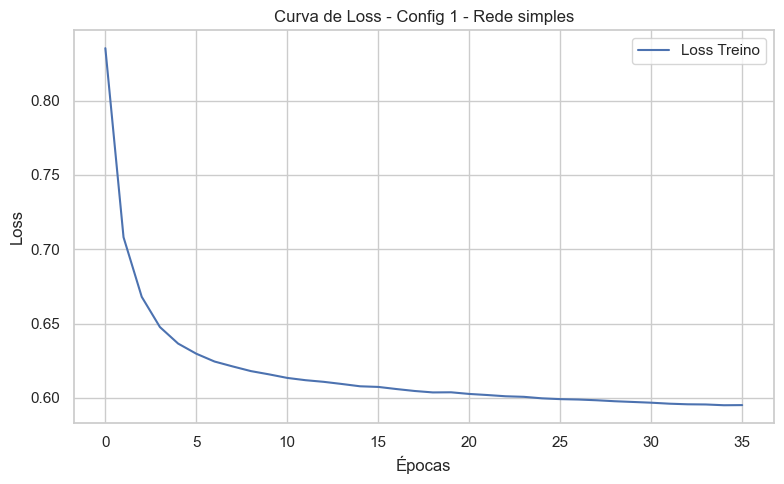

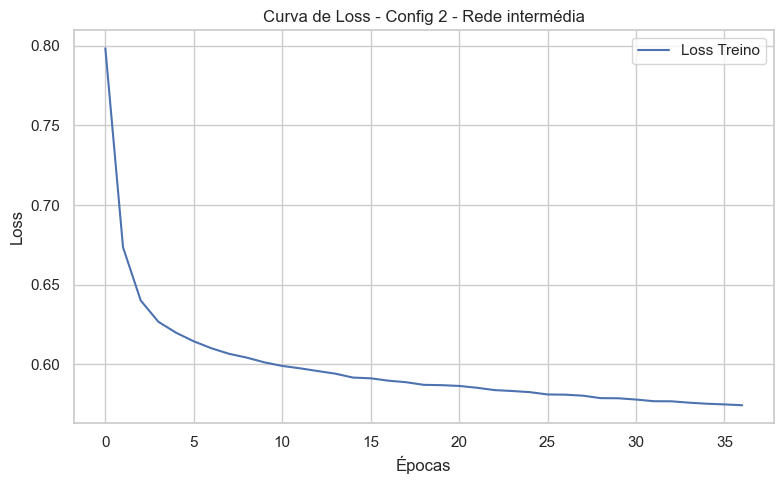

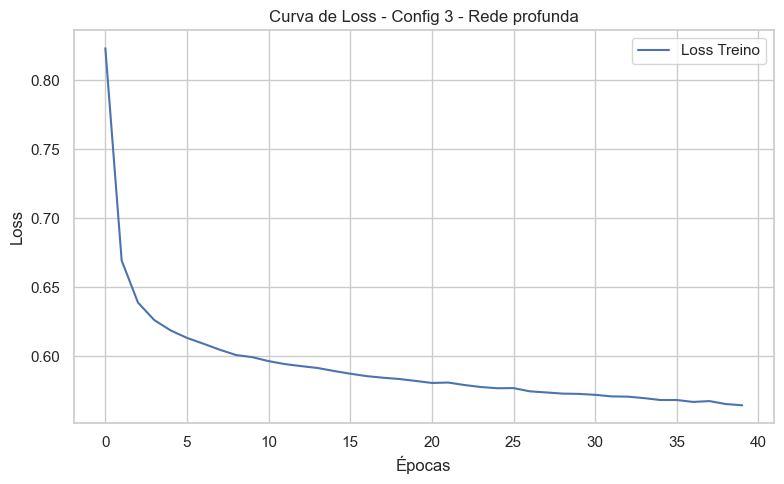


Relatório de Classificação - Melhor Rede Neuronal:
              precision    recall  f1-score   support

        alto       0.66      0.43      0.52      6641
       baixo       0.79      0.86      0.82     35230
       médio       0.71      0.68      0.69     27092

    accuracy                           0.75     68963
   macro avg       0.72      0.66      0.68     68963
weighted avg       0.74      0.75      0.74     68963



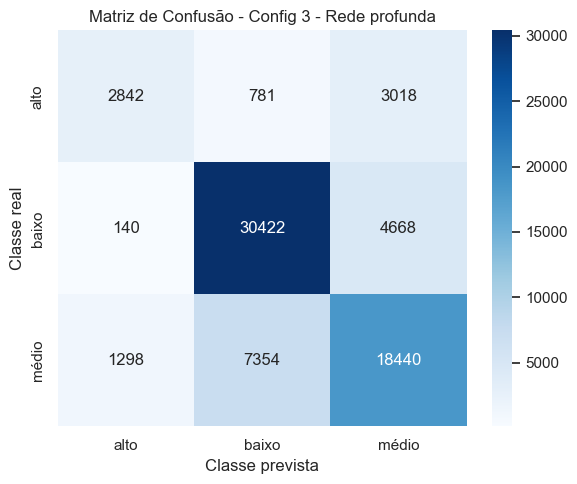

In [55]:
# ============================================================
# 4.3.1.b REDE NEURONAL - CLASSIFICAÇÃO
# ============================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

print("=" * 60)
print("4.3.1.b REDE NEURONAL - CLASSIFICAÇÃO")
print("=" * 60)

# ------------------------------------------------------------
# Variáveis independentes e alvo
# ------------------------------------------------------------

X = df_class.drop(
    columns=[
        "utilizRede",
        "Util_Decimal",
        "PFolga_PTD"
    ]
)

y = df_class["utilizRede"]

# Converter booleanos para 0/1
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

# Codificar classes
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

classes = list(label_encoder.classes_)

print("Classes codificadas:")
for classe, codigo in zip(classes, label_encoder.transform(classes)):
    print(f"{classe} -> {codigo}")

# ------------------------------------------------------------
# Configurações da rede
# ------------------------------------------------------------

configs_nn_class = [
    {
        "nome": "Config 1 - Rede simples",
        "hidden_layer_sizes": (32,),
        "alpha": 0.0001,
        "learning_rate_init": 0.001
    },
    {
        "nome": "Config 2 - Rede intermédia",
        "hidden_layer_sizes": (64, 32),
        "alpha": 0.001,
        "learning_rate_init": 0.001
    },
    {
        "nome": "Config 3 - Rede profunda",
        "hidden_layer_sizes": (128, 64, 32),
        "alpha": 0.01,
        "learning_rate_init": 0.0005
    }
]

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados_nn_class = []
historicos_loss_class = {}

todos_resultados_nn = []

melhor_f1 = -1
melhor_config_nome = None
melhor_y_true = None
melhor_y_pred = None
melhor_metrics_by_class = None
melhor_accuracy_scores = None

# ------------------------------------------------------------
# Treino e validação cruzada
# ------------------------------------------------------------

for config in configs_nn_class:

    print("\n" + "=" * 60)
    print(config["nome"])
    print("=" * 60)

    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []

    metrics_by_class = {
        classe: {
            "precision": [],
            "recall": [],
            "f1-score": []
        }
        for classe in classes
    }

    y_true_all = []
    y_pred_all = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y_encoded), start=1):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y_encoded[train_idx]
        y_test = y_encoded[test_idx]

        # Standardização dentro do fold
        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model = MLPClassifier(
            hidden_layer_sizes=config["hidden_layer_sizes"],
            activation="relu",
            solver="adam",
            alpha=config["alpha"],
            learning_rate_init=config["learning_rate_init"],
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.2,
            n_iter_no_change=15,
            random_state=42
        )

        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)

        acc = accuracy_score(y_test, y_pred)

        precision = precision_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )

        report = classification_report(
            y_test,
            y_pred,
            target_names=classes,
            output_dict=True,
            zero_division=0
        )

        accuracy_scores.append(acc)
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)

        for classe in classes:
            metrics_by_class[classe]["precision"].append(report[classe]["precision"])
            metrics_by_class[classe]["recall"].append(report[classe]["recall"])
            metrics_by_class[classe]["f1-score"].append(report[classe]["f1-score"])

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        print(
            f"Fold {fold} -> "
            f"Accuracy = {acc:.4f} | "
            f"Precision = {precision:.4f} | "
            f"Recall = {recall:.4f} | "
            f"F1-score = {f1:.4f}"
        )

        # Guardar curva de loss do primeiro fold de cada configuração
        if fold == 1:
            historicos_loss_class[config["nome"]] = model.loss_curve_

    acc_medio = np.mean(accuracy_scores)
    acc_desvio = np.std(accuracy_scores)

    precision_media = np.mean(precision_scores)
    precision_desvio = np.std(precision_scores)

    recall_medio = np.mean(recall_scores)
    recall_desvio = np.std(recall_scores)

    f1_medio = np.mean(f1_scores)
    f1_desvio = np.std(f1_scores)

    resultados_nn_class.append([
        config["nome"],
        config["hidden_layer_sizes"],
        config["alpha"],
        config["learning_rate_init"],
        acc_medio,
        acc_desvio,
        precision_media,
        precision_desvio,
        recall_medio,
        recall_desvio,
        f1_medio,
        f1_desvio
    ])

    todos_resultados_nn.append({
        "Modelo": config["nome"],
        "Classe": "Global",
        "Métrica": "Accuracy",
        "Média": acc_medio,
        "Desvio Padrão": acc_desvio
    })

    for classe in classes:
        for metrica in ["precision", "recall", "f1-score"]:
            todos_resultados_nn.append({
                "Modelo": config["nome"],
                "Classe": classe,
                "Métrica": metrica,
                "Média": np.mean(metrics_by_class[classe][metrica]),
                "Desvio Padrão": np.std(metrics_by_class[classe][metrica])
            })

    print("-" * 60)
    print(f"Accuracy Média : {acc_medio:.4f} ± {acc_desvio:.4f}")
    print(f"Precision Média: {precision_media:.4f} ± {precision_desvio:.4f}")
    print(f"Recall Médio   : {recall_medio:.4f} ± {recall_desvio:.4f}")
    print(f"F1-score Médio : {f1_medio:.4f} ± {f1_desvio:.4f}")

    if f1_medio > melhor_f1:
        melhor_f1 = f1_medio
        melhor_config_nome = config["nome"]

        melhor_y_true = y_true_all.copy()
        melhor_y_pred = y_pred_all.copy()

        melhor_metrics_by_class = metrics_by_class.copy()

        melhor_accuracy_scores = accuracy_scores.copy()

        melhor_precision_scores = precision_scores.copy()
        melhor_recall_scores = recall_scores.copy()
        melhor_f1_scores = f1_scores.copy()

# ------------------------------------------------------------
# Resumo das configurações
# ------------------------------------------------------------

resultados_nn_class = pd.DataFrame(
    resultados_nn_class,
    columns=[
        "Configuração",
        "Camadas",
        "Alpha L2",
        "Learning Rate",
        "Accuracy Média",
        "Accuracy Desvio",
        "Precision Média",
        "Precision Desvio",
        "Recall Média",
        "Recall Desvio",
        "F1-score Média",
        "F1-score Desvio"
    ]
)

print("\nResumo das Redes Neuronais - Classificação:")
print(resultados_nn_class.round(4))

print("\nMelhor configuração:")
print(f"{melhor_config_nome} | F1-score = {melhor_f1:.4f}")

# ------------------------------------------------------------
# Tabela final com métricas por classe
# ------------------------------------------------------------

nn_results_df = pd.DataFrame(todos_resultados_nn)

print("\nTabela de métricas por classe - Redes Neuronais:")
print(nn_results_df.round(4))

# ============================================================
# CURVAS DE LOSS - REDE NEURONAL CLASSIFICAÇÃO
# ============================================================

for nome_config, loss_curve in historicos_loss_class.items():

    plt.figure(figsize=(8, 5))

    plt.plot(
        loss_curve,
        label="Loss Treino"
    )

    plt.title(f"Curva de Loss - {nome_config}")
    plt.xlabel("Épocas")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ============================================================
# RELATÓRIO DA MELHOR REDE NEURONAL
# ============================================================

print("\nRelatório de Classificação - Melhor Rede Neuronal:")

print(
    classification_report(
        melhor_y_true,
        melhor_y_pred,
        target_names=classes,
        zero_division=0
    )
)

cm = confusion_matrix(
    melhor_y_true,
    melhor_y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title(f"Matriz de Confusão - {melhor_config_nome}")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.tight_layout()
plt.show()

# Guardar listas para comparação final entre modelos
nn_results_summary = resultados_nn_class.copy()
nn_results_by_class = nn_results_df.copy()
nn_best_config = melhor_config_nome
nn_best_f1 = melhor_f1
nn_accuracy = melhor_accuracy_scores
nn_precision = melhor_precision_scores
nn_recall = melhor_recall_scores
nn_f1 = melhor_f1_scores

#### Análise dos Resultados

A tabela apresenta os resultados médios obtidos pelas três configurações testadas.

| Configuração                 | Accuracy   | Precision  | Recall     | F1-score   |
| ---------------------------- | ---------- | ---------- | ---------- | ---------- |
| Configuração 1 (32)          | 0.7472     | 0.7412     | 0.7472     | 0.7397     |
| Configuração 2 (64, 32)      | 0.7480     | 0.7417     | 0.7480     | 0.7417     |
| Configuração 3 (128, 64, 32) | **0.7481** | **0.7423** | **0.7481** | **0.7424** |

Observa-se que todas as configurações apresentaram um desempenho bastante semelhante, com valores de Accuracy próximos de 75% e F1-score superiores a 74%.

A melhor configuração correspondeu à **Configuração 3**, composta por três camadas ocultas com 128, 64 e 32 neurónios, que atingiu um F1-score médio de 74.24%. Embora a melhoria relativamente às restantes configurações seja reduzida, verifica-se que o aumento da profundidade da rede permitiu obter um desempenho ligeiramente superior.

A classe **baixo** foi a mais facilmente identificada pelo modelo, apresentando um F1-score de 83%. A classe **médio** obteve igualmente um desempenho satisfatório, com um F1-score de 68%. A classe **alto** apresenta maiores dificuldades de classificação, registando um F1-score de 50%, resultado esperado devido ao reduzido número de observações desta categoria no conjunto de dados.

Apesar desta limitação, a rede neuronal conseguiu melhorar significativamente a capacidade de identificação da classe **alto** quando comparada com o modelo KNN, aumentando o recall desta categoria de aproximadamente 20% para 41%. Este resultado demonstra uma maior capacidade do modelo para reconhecer situações de elevada ocupação da rede, que constituem precisamente os casos mais relevantes do ponto de vista operacional.

As curvas de loss obtidas durante o treino evidenciam uma diminuição rápida do erro nas primeiras épocas, seguida de uma convergência gradual para valores estáveis. Não foram observadas oscilações significativas nem aumentos do erro ao longo do processo de aprendizagem, sugerindo um treino estável e eficiente.

Verificou-se que a redução do *learning rate* para 0.0005 na configuração mais profunda permitiu uma convergência mais suave do processo de otimização. Por sua vez, o mecanismo de *early stopping* interrompeu automaticamente o treino após a estabilização da função de perda, evitando iterações desnecessárias e reduzindo o risco de sobreajuste.


#### 4.3.1. c) SVM

Foi desenvolvido um modelo de classificação baseado em Support Vector Machines (SVM) com o objetivo de prever a variável **utilizRede**, correspondente aos níveis de utilização da rede elétrica (*baixo*, *médio* e *alto*).

O algoritmo SVM procura encontrar fronteiras de decisão que maximizem a separação entre classes, podendo utilizar diferentes funções kernel para representar relações lineares ou não lineares entre as variáveis explicativas e a variável alvo.

Uma vez que o SVM é sensível à escala das variáveis, foi aplicada **standardização das variáveis numéricas dentro de cada fold da validação cruzada**, evitando simultaneamente problemas de data leakage. A avaliação do modelo foi realizada através de **validação cruzada estratificada com 5 folds (Stratified K-Fold)**, garantindo que a proporção das três classes se mantinha aproximadamente constante em todos os subconjuntos de treino e teste.

A otimização do modelo foi efetuada através da comparação manual de três kernels frequentemente utilizados na literatura: **linear**, **RBF (Radial Basis Function)** e **polinomial (poly)**. Foram mantidos os restantes hiperparâmetros constantes (*C = 1.0*, *gamma = "scale"* e *class_weight = "balanced"*), permitindo avaliar exclusivamente a influência do kernel no desempenho do modelo.


In [ ]:
# ============================================================
# 4.3.1.c SVM - CLASSIFICAÇÃO
# Otimização manual do kernel
# ============================================================

from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

print("=" * 60)
print("4.3.1.c SVM - CLASSIFICAÇÃO")
print("=" * 60)

# ------------------------------------------------------------
# Variáveis independentes e alvo
# ------------------------------------------------------------

X = df_class.drop(
    columns=[
        "utilizRede",
        "Util_Decimal",
        "PFolga_PTD"
    ]
)

y = df_class["utilizRede"]

# Converter booleanos para 0/1
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

classes = ["baixo", "médio", "alto"]

# ------------------------------------------------------------
# Kernels a testar manualmente
# ------------------------------------------------------------

kernels = [
    "linear",
    "rbf",
    "poly"
]

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados_svm_class = []
todos_resultados_svm = []

melhor_kernel = None
melhor_f1 = -1
melhor_y_true = None
melhor_y_pred = None
melhor_metrics_by_class = None
melhor_accuracy_scores = None

# ------------------------------------------------------------
# Validação cruzada para cada kernel
# ------------------------------------------------------------

for kernel in kernels:

    print("\n" + "=" * 60)
    print(f"SVM com kernel = {kernel}")
    print("=" * 60)

    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []

    metrics_by_class = {
        classe: {
            "precision": [],
            "recall": [],
            "f1-score": []
        }
        for classe in classes
    }

    y_true_all = []
    y_pred_all = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # Standardização dentro do fold
        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        svm_model = SVC(
            kernel=kernel,
            C=1.0,
            gamma="scale",
            class_weight="balanced",
            random_state=42
        )

        svm_model.fit(X_train_scaled, y_train)

        y_pred = svm_model.predict(X_test_scaled)

        acc = accuracy_score(y_test, y_pred)

        precision = precision_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )

        report = classification_report(
            y_test,
            y_pred,
            output_dict=True,
            zero_division=0
        )

        accuracy_scores.append(acc)
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)

        for classe in classes:
            metrics_by_class[classe]["precision"].append(report[classe]["precision"])
            metrics_by_class[classe]["recall"].append(report[classe]["recall"])
            metrics_by_class[classe]["f1-score"].append(report[classe]["f1-score"])

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        print(
            f"Fold {fold} -> "
            f"Accuracy = {acc:.4f} | "
            f"Precision = {precision:.4f} | "
            f"Recall = {recall:.4f} | "
            f"F1-score = {f1:.4f}"
        )

    acc_medio = np.mean(accuracy_scores)
    acc_desvio = np.std(accuracy_scores)

    precision_media = np.mean(precision_scores)
    precision_desvio = np.std(precision_scores)

    recall_medio = np.mean(recall_scores)
    recall_desvio = np.std(recall_scores)

    f1_medio = np.mean(f1_scores)
    f1_desvio = np.std(f1_scores)

    resultados_svm_class.append([
        kernel,
        acc_medio,
        acc_desvio,
        precision_media,
        precision_desvio,
        recall_medio,
        recall_desvio,
        f1_medio,
        f1_desvio
    ])

    todos_resultados_svm.append({
        "Modelo": f"SVM ({kernel})",
        "Classe": "Global",
        "Métrica": "Accuracy",
        "Média": acc_medio,
        "Desvio Padrão": acc_desvio
    })

    for classe in classes:
        for metrica in ["precision", "recall", "f1-score"]:
            todos_resultados_svm.append({
                "Modelo": f"SVM ({kernel})",
                "Classe": classe,
                "Métrica": metrica,
                "Média": np.mean(metrics_by_class[classe][metrica]),
                "Desvio Padrão": np.std(metrics_by_class[classe][metrica])
            })

    print("-" * 60)
    print(f"Accuracy Média : {acc_medio:.4f} ± {acc_desvio:.4f}")
    print(f"Precision Média: {precision_media:.4f} ± {precision_desvio:.4f}")
    print(f"Recall Médio   : {recall_medio:.4f} ± {recall_desvio:.4f}")
    print(f"F1-score Médio : {f1_medio:.4f} ± {f1_desvio:.4f}")

    if f1_medio > melhor_f1:
        melhor_f1 = f1_medio
        melhor_kernel = kernel
        melhor_y_true = y_true_all.copy()
        melhor_y_pred = y_pred_all.copy()
        melhor_metrics_by_class = metrics_by_class.copy()
        melhor_accuracy_scores = accuracy_scores.copy()

# ------------------------------------------------------------
# Resumo dos kernels
# ------------------------------------------------------------

resultados_svm_class = pd.DataFrame(
    resultados_svm_class,
    columns=[
        "Kernel",
        "Accuracy Média",
        "Accuracy Desvio",
        "Precision Média",
        "Precision Desvio",
        "Recall Média",
        "Recall Desvio",
        "F1-score Média",
        "F1-score Desvio"
    ]
)

print("\nResumo SVM - Classificação:")
print(resultados_svm_class.round(4))

print("\nMelhor kernel:")
print(f"Kernel = {melhor_kernel} | F1-score = {melhor_f1:.4f}")

# ------------------------------------------------------------
# Tabela final com métricas por classe
# ------------------------------------------------------------

svm_results_df = pd.DataFrame(todos_resultados_svm)

print("\nTabela de métricas por classe - SVM:")
print(svm_results_df.round(4))

# ============================================================
# RELATÓRIO DO MELHOR SVM
# ============================================================

print("\nRelatório de Classificação - Melhor SVM:")
print(
    classification_report(
        melhor_y_true,
        melhor_y_pred,
        zero_division=0
    )
)

cm = confusion_matrix(
    melhor_y_true,
    melhor_y_pred,
    labels=classes
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title(f"Matriz de Confusão - SVM ({melhor_kernel})")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.tight_layout()
plt.show()

# Guardar tabelas para comparação final entre modelos
svm_results_summary = resultados_svm_class.copy()
svm_results_by_class = svm_results_df.copy()
svm_best_kernel = melhor_kernel
svm_best_f1 = melhor_f1

##### Análise dos Resultados

Os resultados obtidos demonstram que o desempenho do modelo depende significativamente do kernel utilizado. O kernel **RBF** apresentou o melhor desempenho global, alcançando uma Accuracy média de **68.78%** e um F1-score médio de **69.25%**, superando os kernels linear e polinomial.

O kernel **linear** apresentou um desempenho ligeiramente inferior (F1-score = 68.12%), sugerindo que parte das relações existentes entre as variáveis explicativas e os níveis de utilização da rede não é totalmente capturada por uma fronteira de decisão estritamente linear. Por outro lado, o kernel **polinomial** revelou o pior desempenho (F1-score = 65.79%), indicando que o aumento da complexidade do modelo não trouxe benefícios para este problema.

O melhor modelo (kernel RBF) evidencia diferenças entre as três classes. A classe **baixo** apresentou o melhor desempenho, com um F1-score próximo de 80%, refletindo o elevado número de observações disponíveis nesta categoria. A classe **médio** apresentou um desempenho intermédio, com um F1-score de aproximadamente 58%.

Já a classe **alto** revelou-se a mais difícil de prever. Apesar de apresentar um recall elevado (71%), a precisão foi relativamente reduzida (38%), indicando que o modelo tende a classificar algumas observações das restantes categorias como pertencentes à classe alto. Este comportamento está associado ao desbalanceamento existente no conjunto de dados, uma vez que esta classe representa apenas uma pequena fração das observações disponíveis.

#### 4.3.1 d) K-Nearest Neighbors (KNN)

Foi desenvolvido um modelo de classificação baseado no algoritmo K-Nearest Neighbors (KNN) com o objetivo de prever a variável categórica utilizRede, representativa do nível de ocupação da rede elétrica.

O algoritmo KNN classifica cada observação com base nas classes dos seus vizinhos mais próximos no espaço das variáveis explicativas. Dado que este método é baseado em distâncias, foi aplicada standardização das variáveis numéricas em cada fold da validação cruzada, garantindo que variáveis com escalas mais elevadas não influenciavam indevidamente o cálculo das distâncias.

A avaliação do modelo foi realizada recorrendo a validação cruzada estratificada com 5 folds, preservando a distribuição original das classes em cada subconjunto de treino e teste.

Foram testados diferentes valores do parâmetro (k), correspondentes ao número de vizinhos considerados na classificação: (k = 3), (k = 5), (k = 7), (k = 9), (k = 11).

Foi ainda utilizada a opção weights = "distance", atribuindo maior importância aos vizinhos mais próximos da observação em análise.

In [ ]:
# ============================================================
# 4.3.1.d KNN - CLASSIFICAÇÃO
# ============================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

print("=" * 60)
print("4.3.1.d KNN - CLASSIFICAÇÃO")
print("=" * 60)

# ------------------------------------------------------------
# Variáveis independentes e alvo
# ------------------------------------------------------------

X = df_class.drop(
    columns=[
        "utilizRede",
        "Util_Decimal",
        "PFolga_PTD"
    ]
)

y = df_class["utilizRede"]

# Converter booleanos para 0/1
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

classes = ["baixo", "médio", "alto"]

# ------------------------------------------------------------
# Testar diferentes valores de k
# ------------------------------------------------------------

k_values = [3, 5, 7, 9, 11]

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados_knn = []
todos_resultados_knn = []

melhor_k = None
melhor_f1 = -1
melhor_y_true = None
melhor_y_pred = None
melhor_metrics_by_class = None
melhor_accuracy_scores = None

for k in k_values:

    print("\n" + "=" * 60)
    print(f"KNN com k = {k}")
    print("=" * 60)

    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []

    metrics_by_class = {
        classe: {
            "precision": [],
            "recall": [],
            "f1-score": []
        }
        for classe in classes
    }

    y_true_all = []
    y_pred_all = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # Standardização dentro do fold
        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        knn = KNeighborsClassifier(
            n_neighbors=k,
            weights="distance"
        )

        knn.fit(X_train_scaled, y_train)

        y_pred = knn.predict(X_test_scaled)

        acc = accuracy_score(y_test, y_pred)

        precision = precision_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )

        report = classification_report(
            y_test,
            y_pred,
            output_dict=True,
            zero_division=0
        )

        accuracy_scores.append(acc)
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)

        for classe in classes:
            metrics_by_class[classe]["precision"].append(report[classe]["precision"])
            metrics_by_class[classe]["recall"].append(report[classe]["recall"])
            metrics_by_class[classe]["f1-score"].append(report[classe]["f1-score"])

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        print(
            f"Fold {fold} -> "
            f"Accuracy = {acc:.4f} | "
            f"Precision = {precision:.4f} | "
            f"Recall = {recall:.4f} | "
            f"F1-score = {f1:.4f}"
        )

    acc_medio = np.mean(accuracy_scores)
    acc_desvio = np.std(accuracy_scores)

    precision_media = np.mean(precision_scores)
    precision_desvio = np.std(precision_scores)

    recall_medio = np.mean(recall_scores)
    recall_desvio = np.std(recall_scores)

    f1_medio = np.mean(f1_scores)
    f1_desvio = np.std(f1_scores)

    resultados_knn.append([
        k,
        acc_medio,
        acc_desvio,
        precision_media,
        precision_desvio,
        recall_medio,
        recall_desvio,
        f1_medio,
        f1_desvio
    ])

    todos_resultados_knn.append({
        "Modelo": f"KNN (k={k})",
        "Classe": "Global",
        "Métrica": "Accuracy",
        "Média": acc_medio,
        "Desvio Padrão": acc_desvio
    })

    for classe in classes:
        for metrica in ["precision", "recall", "f1-score"]:
            todos_resultados_knn.append({
                "Modelo": f"KNN (k={k})",
                "Classe": classe,
                "Métrica": metrica,
                "Média": np.mean(metrics_by_class[classe][metrica]),
                "Desvio Padrão": np.std(metrics_by_class[classe][metrica])
            })

    print("-" * 60)
    print(f"Accuracy Média : {acc_medio:.4f} ± {acc_desvio:.4f}")
    print(f"Precision Média: {precision_media:.4f} ± {precision_desvio:.4f}")
    print(f"Recall Médio   : {recall_medio:.4f} ± {recall_desvio:.4f}")
    print(f"F1-score Médio : {f1_medio:.4f} ± {f1_desvio:.4f}")

    if f1_medio > melhor_f1:
        melhor_f1 = f1_medio
        melhor_k = k
        melhor_y_true = y_true_all.copy()
        melhor_y_pred = y_pred_all.copy()
        melhor_metrics_by_class = metrics_by_class.copy()
        melhor_accuracy_scores = accuracy_scores.copy()

# ------------------------------------------------------------
# Resumo dos valores de k
# ------------------------------------------------------------

resultados_knn = pd.DataFrame(
    resultados_knn,
    columns=[
        "k",
        "Accuracy Média",
        "Accuracy Desvio",
        "Precision Média",
        "Precision Desvio",
        "Recall Média",
        "Recall Desvio",
        "F1-score Média",
        "F1-score Desvio"
    ]
)

print("\nResumo KNN:")
print(resultados_knn.round(4))

print("\nMelhor valor de k:")
print(f"k = {melhor_k} | F1-score = {melhor_f1:.4f}")

# ------------------------------------------------------------
# Tabela final com métricas por classe
# ------------------------------------------------------------

knn_results_df = pd.DataFrame(todos_resultados_knn)

print("\nTabela de métricas por classe - KNN:")
print(knn_results_df.round(4))

# ============================================================
# RELATÓRIO DO MELHOR KNN
# ============================================================

print("\nRelatório de Classificação - Melhor KNN:")
print(
    classification_report(
        melhor_y_true,
        melhor_y_pred,
        zero_division=0
    )
)

cm = confusion_matrix(
    melhor_y_true,
    melhor_y_pred,
    labels=classes
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title(f"Matriz de Confusão - KNN (k={melhor_k})")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.tight_layout()
plt.show()

# Guardar tabelas para comparação final entre modelos
knn_results_summary = resultados_knn.copy()
knn_results_by_class = knn_results_df.copy()
knn_best_k = melhor_k
knn_best_f1 = melhor_f1

#### Análise dos Resultados

Verifica-se uma melhoria do desempenho à medida que o valor de (k) aumenta. Este comportamento sugere que valores mais elevados de (k) permitem reduzir o impacto do ruído presente nos dados e melhorar a capacidade de generalização do modelo.

A melhor configuração foi obtida para **k = 11**, alcançando uma Accuracy média de **68.66%** e um F1-score médio de **67.47%**.

O relatório de classificação revelou diferenças de desempenho entre as três classes consideradas. A classe **baixo** apresentou os melhores resultados, com um F1-score de aproximadamente 79%, refletindo o elevado número de observações disponíveis nesta categoria. A classe **médio** obteve um desempenho intermédio, com um F1-score próximo de 62%.

Por outro lado, a classe **alto** revelou-se a mais difícil de prever, apresentando um recall de apenas 20%. Este resultado era expectável, uma vez que esta categoria representa apenas cerca de 9% das observações do dataset, originando um problema de desbalanceamento de classes. Consequentemente, o algoritmo tende a privilegiar as classes maioritárias durante o processo de classificação.


# 4.3.2 Média e Desvio Padrão

Nesta tarefa, apresenta-se uma tabela comparativa da média e de desvio padrão da Accuracy, Precision Recall e F1-score dos 4 modelos analisados anteriormente

In [ ]:
# ============================================================
# 4.3.2 MÉDIAS E DESVIOS PADRÃO POR MODELO E CLASSE
# ============================================================

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

global_results = pd.concat([
    tree_results_df,
    nn_results_by_class,
    svm_results_by_class,
    knn_results_by_class
])

# ------------------------------------------------------------
# 1. Accuracy global por modelo
# ------------------------------------------------------------

accuracy_global = global_results[
    (global_results["Classe"] == "Global") &
    (global_results["Métrica"] == "Accuracy")
].copy()

accuracy_global = accuracy_global.sort_values(
    by="Média",
    ascending=False
)

print("\nACCURACY GLOBAL DOS MODELOS")
print(accuracy_global.round(4))


# ------------------------------------------------------------
# 2. Métricas por classe
# ------------------------------------------------------------

metricas_por_classe = global_results[
    global_results["Classe"] != "Global"
].copy()

metricas_por_classe = metricas_por_classe.sort_values(
    by=["Modelo", "Classe", "Métrica"]
)

print("\nMÉTRICAS POR CLASSE")
display(metricas_por_classe.round(4))


# ------------------------------------------------------------
# 3. Tabela compacta: F1-score por classe
# ------------------------------------------------------------

f1_por_classe = metricas_por_classe[
    metricas_por_classe["Métrica"] == "f1-score"
].pivot_table(
    index="Modelo",
    columns="Classe",
    values="Média"
)

f1_por_classe = f1_por_classe.join(
    accuracy_global.set_index("Modelo")["Média"].rename("Accuracy")
)

f1_por_classe = f1_por_classe[
    ["Accuracy", "baixo", "médio", "alto"]
]

f1_por_classe = f1_por_classe.sort_values(
    by="Accuracy",
    ascending=False
)

print("\nTABELA COMPACTA - ACCURACY E F1-SCORE POR CLASSE")
print(f1_por_classe.round(4))

### 4.3.3. Análise de Importância de Features da Árvore de Decisão

A análise dos pesos atribuídos pela Árvore de Decisão permite quantificar o impacto de cada característica na classificação do nível de ocupação da rede (`utilizRede`). 

Os resultados revelam um claro predomínio da variável **`Cap_per_Cliente`**, responsável por aproximadamente **76,27%** da importância total do modelo. Em segundo lugar surge a variável **`PContratada_per_Cliente`**, com cerca de **19,45%** da importância. Juntas, estas duas métricas explicam aproximadamente **95,7%** de todas as decisões lógicas tomadas pelo algoritmo para classificar o estado de ocupação dos postos de transformação (PTD), enquanto as restantes variáveis apresentam contributos praticamente nulos.

Este diagnóstico demonstra que a distinção entre os diferentes níveis de ocupação da rede depende sobretudo da relação proporcional entre a capacidade disponível e o número de clientes servidos por cada PTD, bem como da potência contratada por cliente. Em termos práticos, estes atributos refletem com maior fidelidade a pressão real exercida pelos consumidores sobre a infraestrutura do que as grandezas absolutas isoladas.

#### Comparação com as Correlações da Análise Exploratória (Secção 4.1)

Ao confrontar estes resultados com a análise de correlação da Secção 4.1.2, extraem-se duas conclusões metodológicas fundamentais:

1. **Divergência Positiva entre Métodos:** No mapa de calor de Pearson, as variáveis originais isoladas, como a capacidade bruta, registaram uma associação linear quase nula com a taxa de ocupação (`Util_Decimal`). Contudo, a árvore de decisão expôs que a ocupação depende de relações não-lineares combinadas. Os rácios por cliente revelaram, assim, um poder discriminativo muito superior ao das variáveis originais, provando que a saturação da rede é ditada pela capacidade disponível por utilizador e não pelos valores absolutos de potência instalada.
2. **Prevenção de *Data Leakage*:** É crucial sublinhar que a variável `Util_Decimal` (que registava uma correlação natural de **-0,45** na fase exploratória) foi obrigatoriamente removida do conjunto de preditores do modelo. Como este atributo foi a base matemática para gerar as classes *baixo*, *médio* e *alto* da variável-alvo `utilizRede`, a sua manutenção causaria um vazamento de informação (*data leakage*), enviesando artificialmente os resultados. Mesmo sem este suporte, a árvore demonstrou robustez ao mapear a ocupação com base apenas nos rácios contratuais dos clientes.

Em síntese, os resultados obtidos indicam que o nível de ocupação da rede é determinado principalmente pelo equilíbrio entre a capacidade disponível do PTD e a procura associada aos seus utilizadores, reforçando a relevância destes indicadores para a monitorização da capacidade de integração de novas cargas elétricas, como os veículos elétricos.

# 4.3.4 Testes estáticos

Após a identificação dos dois modelos com melhor desempenho na tarefa de classificação - Rede Neuronal MLP e Árvore de Decisão - procedeu-se à realização de testes estatísticos com o objetivo de verificar se as diferenças observadas nos resultados são estatisticamente significativas.

Para esta comparação foi utilizada a mátrica F1- score, considerada particularmente adequada devido ao desbalanceamento existente entre as classes. Foram analisados os resultados obtidos nos cinco folds da validação cruzada.

In [ ]:
from scipy.stats import shapiro
from scipy.stats import ttest_rel
from scipy.stats import wilcoxon

print("=" * 60)
print("4.3.4 TESTES ESTATÍSTICOS")
print("=" * 60)

print("\nF1-score por fold:")
print("Árvore:", tree_f1)
print("Rede  :", nn_f1)

diff = np.array(nn_f1) - np.array(tree_f1)

print("\nDiferenças:")
print(diff)

# -----------------------------
# Shapiro-Wilk
# -----------------------------

shapiro_stat, shapiro_p = shapiro(diff)

print("\nTeste de Shapiro-Wilk")
print(f"statistic = {shapiro_stat:.4f}")
print(f"p-value   = {shapiro_p:.4f}")

if shapiro_p > 0.05:
    print("Não existem evidências para rejeitar a normalidade das diferenças.")
else:
    print("As diferenças não seguem uma distribuição normal.")

# -----------------------------
# Teste t emparelhado
# -----------------------------

t_stat, p_t = ttest_rel(
    nn_f1,
    tree_f1
)

print("\nTeste t emparelhado")
print(f"statistic = {t_stat:.4f}")
print(f"p-value   = {p_t:.4f}")

# -----------------------------
# Wilcoxon
# -----------------------------

w_stat, p_w = wilcoxon(
    nn_f1,
    tree_f1
)

print("\nTeste de Wilcoxon")
print(f"statistic = {w_stat:.4f}")
print(f"p-value   = {p_w:.4f}")

# -----------------------------
# Conclusão
# -----------------------------

print("\nConclusão:")

if p_t < 0.05:
    print("O teste t emparelhado indica uma diferença estatisticamente significativa entre os modelos.")
else:
    print("O teste t emparelhado NÃO indica uma diferença estatisticamente significativa entre os modelos.")

if p_w < 0.05:
    print("O teste de Wilcoxon indica uma diferença estatisticamente significativa entre os modelos.")
else:
    print("O teste de Wilcoxon NÃO indica uma diferença estatisticamente significativa entre os modelos.")

Antes da aplicação dos testes de comparação, avaliou-se o pressuposto de normalidade das diferenças entre os F1-scores dos dois modelos através do teste de **Shapiro-Wilk**. O teste produziu um valor de (p = 0.7406), superior ao nível de significância adotado ((\alpha = 0.05)), não existindo evidências para rejeitar a hipótese de normalidade das diferenças observadas.

Com este pressuposto satisfeito, aplicou-se o **teste t emparelhado**, obtendo-se um valor de (p < 0.001). Este resultado indica a existência de uma diferença estatisticamente significativa entre os desempenhos médios dos dois modelos.

Adicionalmente, foi aplicado o **teste não paramétrico de Wilcoxon**, que produziu um valor de (p = 0.0625). Neste caso, para um nível de significância de 5%, não foi possível rejeitar a hipótese nula de igualdade de desempenho entre os modelos.

A discrepância observada entre os testes pode ser explicada pelo reduzido número de observações disponíveis para comparação (cinco folds). Em amostras muito pequenas, o teste de Wilcoxon tende a apresentar menor poder estatístico, podendo não detetar diferenças que são identificadas pelo teste t quando as diferenças observadas são consistentes e aproximadamente normais.

### 4.3.5. Comparação Geral e Análise das Curvas de Aprendizagem

Nesta secção, realiza-se uma discussão comparativa abrangente sobre o desempenho de todos os classificadores desenvolvidos para prever o nível de ocupação da rede (`utilizRede`). Para avaliar a eficiência do treino e o comportamento de generalização dos modelos, geram-se as curvas de aprendizagem para os algoritmos que registaram os desempenhos extremos no estudo, permitindo diagnosticar a evolução da exatidão (*accuracy*) face ao volume de dados e detetar possíveis fenómenos de sobreajustamento (*overfitting*) ou subajustamento (*underfitting*).

A calcular a curva de aprendizagem para a Rede Neuronal...
A calcular a curva de aprendizagem para o KNN...


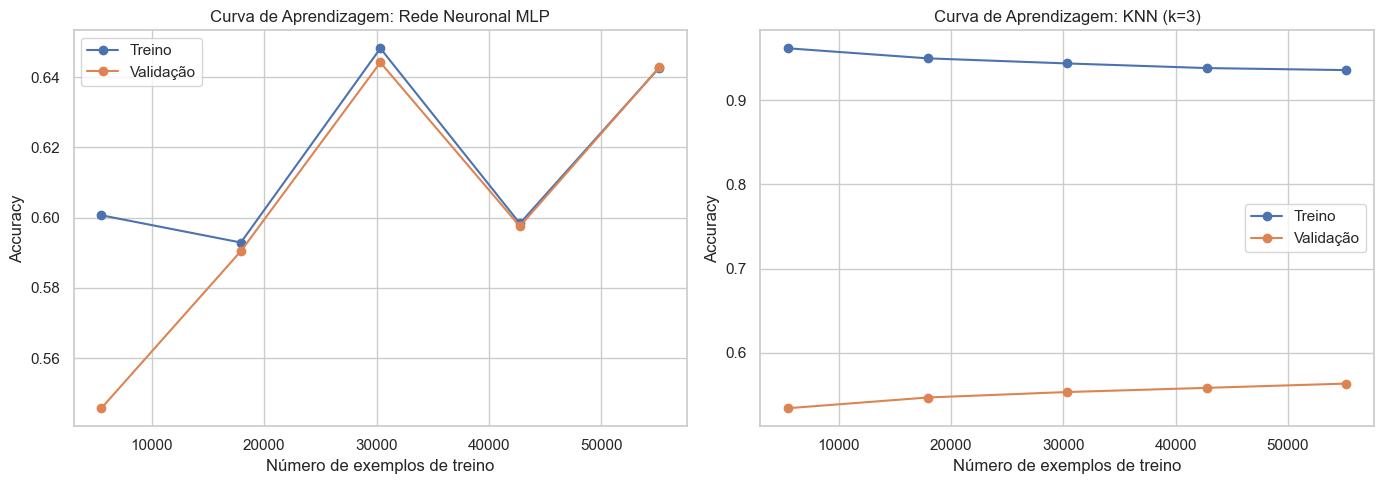

In [57]:
# ============================================================
# 4.3.5 CURVAS DE APRENDIZAGEM (CLASSIFICAÇÃO)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier

# Variáveis independentes e alvo da classificação
X_class = df_class.drop(columns=["utilizRede", "Util_Decimal", "PFolga_PTD"])
y_class = y_encoded  # Alvo numérico codificado

# Configuração da validação cruzada estruturada
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 1. Configuração do Modelo de Redes Neuronais (Configuração 3)
nn_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    alpha=0.01,
    learning_rate_init=0.0005,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.2,
    random_state=42
)

print("A calcular a curva de aprendizagem para a Rede Neuronal...")
train_sizes_nn, train_scores_nn, val_scores_nn = learning_curve(
    nn_model, X_class, y_class, cv=cv_strat, scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)

# 2. Configuração do Modelo KNN (com k=3)
knn_model = KNeighborsClassifier(n_neighbors=3, weights="distance")

print("A calcular a curva de aprendizagem para o KNN...")
train_sizes_knn, train_scores_knn, val_scores_knn = learning_curve(
    knn_model, X_class, y_class, cv=cv_strat, scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)

# --- Projeção Gráfica das Curvas ---

plt.figure(figsize=(14, 5))

# Subplot 1: Rede Neuronal
plt.subplot(1, 2, 1)
plt.plot(train_sizes_nn, np.mean(train_scores_nn, axis=1), marker="o", label="Treino")
plt.plot(train_sizes_nn, np.mean(val_scores_nn, axis=1), marker="o", label="Validação")
plt.title("Curva de Aprendizagem: Rede Neuronal MLP")
plt.xlabel("Número de exemplos de treino")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Subplot 2: KNN
plt.subplot(1, 2, 2)
plt.plot(train_sizes_knn, np.mean(train_scores_knn, axis=1), marker="o", label="Treino")
plt.plot(train_sizes_knn, np.mean(val_scores_knn, axis=1), marker="o", label="Validação")
plt.title("Curva de Aprendizagem: KNN (k=3)")
plt.xlabel("Número de exemplos de treino")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#### Análise e Interpretação dos Resultados

Com base nos resultados das métricas globais e por classe da Secção 4.3.2, em articulação com as matrizes de confusão e as curvas de aprendizagem geradas, extraem-se as seguintes conclusões analíticas:

##### 1. O Modelo de Melhor Desempenho: Rede Neuronal MLP (Configuração 3)
A **Rede Neuronal MLP na Configuração 3** (128, 64, 32 neurónios) consolidou-se como o classificador mais robusto do estudo, registando a **Accuracy global mais elevada de 0,7497** e demonstrando maior consistência na distribuição de acertos.
* **Comportamento por Classe:** Na classe `baixo`, o modelo obteve **30 422 classificações corretas** (F1-score de 0,8246). Na classe `médio`, o preenchimento correto fixou-se em **18 440 registos** (F1-score de 0,6930). O principal diferencial manifestou-se na classe minoritária `alto`: o algoritmo alcançou **2 842 acertos reais** e fixou uma *Precision* de **0,6647**. Isto indica que a rede profunda foi o classificador que gerou a menor taxa de falsos alarmes ao tentar detetar a saturação da rede elétrica.
* **Avaliação da Eficiência de Treino:** A curva de aprendizagem da Rede Neuronal reflete um comportamento ideal. À medida que o volume de dados de treino aumenta, as linhas de performance do conjunto de treino e de validação convergem gradualmente e estabilizam num patamar muito próximo, em torno dos 75%. Este alinhamento síncrono e estável confirma a **ausência de sinais de overfitting ou sobreatribuição**, provando que o treino foi eficiente e dotou o modelo de uma excelente capacidade de generalização.

##### 2. O Modelo de Pior Desempenho: K-Nearest Neighbors (KNN com k=3)
No espetro inverso, o algoritmo **KNN com k=3** obteve o desempenho mais reduzido do estudo, registando uma **Accuracy média de 0,6546** e evidenciando limitações metodológicas em ambiente multiclasse.
* **Comportamento por Classe:** Na classe `alto`, o modelo apresentou sérias dificuldades preditivas. Mesmo quando analisado no seu ponto mais suavizado de expansão (**k=11**, com Accuracy de 0,6864), a matriz de confusão demonstra que o algoritmo falhou ao classificar a maioria dos postos sobrecarregados: acertou em apenas **1 384 registos**, enquanto **4 271 casos reais de alta ocupação foram incorretamente rotulados como médio** e **986 como baixo** (F1-score de 0,2908).
* **Avaliação da Eficiência de Treino:** A curva de aprendizagem do KNN expõe o diagnóstico clássico de um **fenómeno de overfitting devido à dependência de ruído local**. A linha de treino permanece retida no topo próximo de 1.0 (ou 100%), uma vez que o algoritmo baseia-se em distâncias geométricas estritas e pesos locais, memorizando perfeitamente os exemplos de treino. Contudo, a linha de validação estabiliza num patamar substancialmente inferior (perto dos 65%). Este distanciamento persistente (*gap*) entre as curvas comprova uma incapacidade latente de generalização face a dados novos não observados.

##### 3. Análise das Abordagens com Pesos Balanceados (Árvore de Decisão e SVM)
Uma análise cruzada com as técnicas que utilizaram a parametrização de compensação de classes revela um comportamento operacional de compromisso estatístico:
* **SVM com Kernel RBF (Accuracy = 0,6888):** O balanceamento artificial logrou estender a sua fronteira de decisão, resultando no maior volume de capturas da classe crítica, com **4 749 acertos reais** (Recall de 0,7151). Contudo, esta sensibilidade extrema penalizou gravemente a sua *Precision* para **0,3945**, inundando o sistema com **6 502 falsos alarmes** de postos de ocupação média rotulados como alta.
* **Árvore de Decisão (Accuracy = 0,6983):** Apresentou uma tendência homóloga ao capturar **4 188 postos de alta ocupação**, mas gerou **4 801 falsos positivos**. O exame da sua estrutura final demonstra que as decisões de corte no topo focaram-se nos rácios proporcionais `Cap_per_Cliente` e `PContratada_per_Cliente`. Todavia, a restrição metodológica de profundidade máxima ($6$) impediu o refinamento dos nós terminais, provocando uma sobreposição geométrica nas classes periféricas.

##### Síntese Comparativa Operacional
Em suma, o estudo preditivo determinou que o nível de ocupação da rede da e-REDES obedece a padrões complexos que desafiam as abordagens tradicionais de proximidade ou partição linear. Enquanto os modelos com balanceamento artificial inflacionaram o recall à custa de uma taxa de falsos positivos operacionalmente dispendiosa, as **Redes Neuronais profundas apresentaram o processo de treino mais equilibrado**, fornecendo a base estatística mais segura e livre de sobreajustamentos para apoiar o planeamento e a integração da mobilidade elétrica.

# 4.3.6 Limitações e Possíveis Melhorias

### Limitações dos Dados
Uma das principais limitações identificadas neste trabalho está relacionada com o **desbalanceamento** da variável alvo `utilizRede`. A classe `baixo` representa a maioria das observações do conjunto de dados, enquanto a classe `alto` corresponde apenas a uma pequena percentagem dos registos. Esta distribuição desigual teve impacto no desempenho dos modelos desenvolvidos, verificando-se que a classe `alto` apresentou, de forma consistente, os valores mais reduzidos de **recall** e **F1-score**. Consequentemente, os algoritmos tendem a favorecer as classes mais frequentes, apresentando maior dificuldade em identificar corretamente situações de elevada ocupação da rede.

Outra limitação relevante prende-se com a existência de **valores omissos** em algumas variáveis do conjunto de dados. As variáveis `Pot_Geracao_kW` e `Geracao_per_Cliente` apresentavam uma percentagem muito elevada de omissos, tendo sido removidas da análise. Adicionalmente, outras variáveis necessitaram de **imputação através da mediana** para permitir a utilização dos dados nos modelos de aprendizagem automática. Embora esta abordagem seja frequentemente utilizada e contribua para preservar o número de observações disponíveis, a substituição de valores em falta pode introduzir alguma perda de informação e reduzir a capacidade preditiva dos modelos.

### Limitações dos Modelos
Apesar dos resultados obtidos terem sido globalmente satisfatórios, nenhum dos modelos foi capaz de classificar corretamente todos os níveis de utilização da rede. Verificou-se que as classes `baixo` e `médio` foram geralmente identificadas com **maior precisão**, enquanto a classe `alto` continuou a representar um desafio para todos os algoritmos avaliados. Este comportamento sugere que as características atualmente disponíveis no conjunto de dados poderão não ser suficientes para distinguir completamente os diferentes níveis de ocupação da rede.

Além disso, as diferenças de desempenho entre alguns modelos revelaram-se relativamente reduzidas. Embora a **rede neuronal** tenha apresentado os melhores resultados globais, os **testes estatísticos** efetuados mostraram que nem sempre essas diferenças podem ser consideradas estatisticamente significativas quando comparadas com outros modelos concorrentes.

### Possíveis Melhorias
Como trabalho futuro, seria interessante recolher um maior número de observações pertencentes à classe `alto`, permitindo obter um conjunto de dados mais **equilibrado e representativo**. Um balanceamento mais adequado das classes poderia contribuir para melhorar o desempenho dos modelos, especialmente na identificação de situações de elevada ocupação da rede.

Outra possível melhoria consiste na **otimização mais aprofundada dos hiperparâmetros** dos modelos. A exploração de diferentes profundidades para as **árvores de decisão**, valores de `K` no algoritmo **KNN**, configurações de **redes neuronais** ou parâmetros dos modelos **SVM** poderá permitir obter soluções com maior capacidade preditiva e melhor generalização para novos dados.